In [1]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import scipy.stats as st
from matplotlib.colors import BoundaryNorm
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from matplotlib.figure import Figure
import matplotlib.gridspec as gridspec
import pandas as pd
import datetime
import copy
import seaborn as sns
import colorcet as cc
from sklearn.neighbors import KernelDensity
import warnings

In [2]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (separate runs)
        idate = start_dates[ii]
        idirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(idirs) > 0:
            for dd in idirs:
                # Find track stats file
                fname = sorted(glob.glob(f'{dd}/{domain}/stats/{in_basename}*nc'))
                if len(fname) > 0:
                    files.append(fname[0])
    return files

In [3]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    "20181219", 
    "20190122", 
    # "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
rootdir_les = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'

figdir = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures/'

# Domain 4 boundaries
lon_range = [-65.4, -63.1]
lat_range = [-33.3, -30.8]
gridspacing_d3 = '500m'
gridspacing_d4 = '100m'

# Find LASSO files
files_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2')
files_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3')
files_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4_15min')
wfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_w, 'd2')
wfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd3')
wfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd4_15min')

print(f'Number of stats files (D2): {len(files_d2)}')
print(f'Number of W files (D2): {len(wfiles_d2)}')

print(f'Number of stats files (D3): {len(files_d3)}')
print(f'Number of W files (D3): {len(wfiles_d3)}')

print(f'Number of stats files (D4): {len(files_d4)}')
print(f'Number of W files (D4): {len(wfiles_d4)}')

files_d2, files_d3, files_d4, wfiles_d2, wfiles_d3, wfiles_d4

Number of stats files (D2): 13
Number of W files (D2): 13
Number of stats files (D3): 13
Number of W files (D3): 13
Number of stats files (D4): 13
Number of W files (D4): 13


(['/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs_en03/d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs_en00/d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs_en19/d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs_en18/d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181205/gefs_en01/d2/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181219/eda_en09/d2/stats/trackstats_20181219.1200_20181220.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20190122/gefs_en01/d2/stats/trackstats_20190122.1200_20190123.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20190125/gefs_en11/d2/stats/trackstats_20190125.1200_20190126.0000.nc',
  '/gpfs/wolf/atm

In [4]:
# Read track data (LASSO D2)
dst_d2 = xr.open_mfdataset(files_d2, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
ntracks_d2 = dst_d2.sizes['tracks']
dst_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

# Read W data (LASSO D2)
dsw_d2 = xr.open_mfdataset(wfiles_d2, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d2['tracks'] = np.arange(0, ntracks_d2)

# Combine 2D and 3D datasets by coordinates
ds_d2 = xr.combine_by_coords([dst_d2, dsw_d2], combine_attrs='drop_conflicts')
ntimes_d2 = ds_d2.sizes['times']
ds_d2

Number of tracks (D2): 2481


<xarray.Dataset>
Dimensions:                  (tracks: 2481, times: 60, z: 29, core: 20)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 2477 2478 2479 2480
  * times                    (times) int64 0 1 2 3 4 5 6 ... 54 55 56 57 58 59
  * z                        (z) float64 500.0 1e+03 1.5e+03 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 ... 13 14 15 16 17 18 19
Data variables: (12/49)
    CoreArea_up              (tracks, times, z, core) float32 dask.array<chunksize=(144, 60, 29, 20), meta=np.ndarray>
    CoreMaxW_up              (tracks, times, z, core) float32 dask.array<chunksize=(144, 60, 29, 20), meta=np.ndarray>
    CoreMeanW_up             (tracks, times, z, core) float32 dask.array<chunksize=(144, 60, 29, 20), meta=np.ndarray>
    CoreMassFlux_up          (tracks, times, z, core) float32 dask.array<chunksize=(144, 60, 29, 20), meta=np.ndarray>
    CoreArea_down            (tracks, times, z, core) float32 dask.array<chunksize=(144, 60, 29, 20), meta=np.ndarray>
    CoreMinW_down            (tracks, times, z, core) float32 dask.array<chunksize=(144, 60, 29, 20), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(144,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(144,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(144,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(144,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(144,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(144,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    Contact:               Zhe Feng, zhe.feng@pnnl.gov
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/201...
    startdate:             20181129.1200
    enddate:               20181130.0000
    Title:                 Statistics of each track
    timegap_hour:          0.5
    time_resolution_hour:  0.25
    pixel_radius_km:       2.5

In [5]:
# Read track data (LASSO D3)
dst_d3 = xr.open_mfdataset(files_d3, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
ntracks_d3 = dst_d3.sizes['tracks']
dst_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

# Read W data (LASSO D3)
dsw_d3 = xr.open_mfdataset(wfiles_d3, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d3['tracks'] = np.arange(0, ntracks_d3)

# Combine 2D and 3D datasets by coordinates
ds_d3 = xr.combine_by_coords([dst_d3, dsw_d3], combine_attrs='drop_conflicts')
ntimes_d3 = ds_d3.sizes['times']
ds_d3

Number of tracks (D3): 5923


<xarray.Dataset>
Dimensions:                  (tracks: 5923, times: 60, z: 29, core: 20)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 5919 5920 5921 5922
  * times                    (times) int64 0 1 2 3 4 5 6 ... 54 55 56 57 58 59
  * z                        (z) float64 500.0 1e+03 1.5e+03 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 ... 13 14 15 16 17 18 19
Data variables: (12/49)
    CoreArea_up              (tracks, times, z, core) float32 dask.array<chunksize=(393, 60, 29, 20), meta=np.ndarray>
    CoreMaxW_up              (tracks, times, z, core) float32 dask.array<chunksize=(393, 60, 29, 20), meta=np.ndarray>
    CoreMeanW_up             (tracks, times, z, core) float32 dask.array<chunksize=(393, 60, 29, 20), meta=np.ndarray>
    CoreMassFlux_up          (tracks, times, z, core) float32 dask.array<chunksize=(393, 60, 29, 20), meta=np.ndarray>
    CoreArea_down            (tracks, times, z, core) float32 dask.array<chunksize=(393, 60, 29, 20), meta=np.ndarray>
    CoreMinW_down            (tracks, times, z, core) float32 dask.array<chunksize=(393, 60, 29, 20), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(393,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(393,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(393,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(393,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(393,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(393,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    Contact:               Zhe Feng, zhe.feng@pnnl.gov
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    Title:                 Statistics of each track
    timegap_hour:          0.5
    time_resolution_hour:  0.25
    pixel_radius_km:       0.5

In [6]:
# Read track data (LASSO D4)
# dst_d4 = xr.open_mfdataset(files_d4, concat_dim='tracks', combine='nested').load()
dst_d4 = xr.open_mfdataset(files_d4, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
ntracks_d4 = dst_d4.sizes['tracks']
dst_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (d4): {ntracks_d4}')

# Read W data (LASSO D4)
# dsw_d4 = xr.open_mfdataset(wfiles_d4, concat_dim='tracks', combine='nested').load()
dsw_d4 = xr.open_mfdataset(wfiles_d4, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d4['tracks'] = np.arange(0, ntracks_d4)

# Combine 2D and 3D datasets by coordinates
ds_d4 = xr.combine_by_coords([dst_d4, dsw_d4], combine_attrs='drop_conflicts')
# Trim times dimension to match D3
ds_d4 = ds_d4.isel(times=slice(0, ntimes_d3))
ds_d4

Number of tracks (d4): 2417


<xarray.Dataset>
Dimensions:                  (tracks: 2417, times: 60, z: 29, core: 20)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 2413 2414 2415 2416
  * times                    (times) int64 0 1 2 3 4 5 6 ... 54 55 56 57 58 59
  * z                        (z) float64 500.0 1e+03 1.5e+03 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 ... 13 14 15 16 17 18 19
Data variables: (12/49)
    CoreArea_up              (tracks, times, z, core) float32 dask.array<chunksize=(148, 60, 29, 20), meta=np.ndarray>
    CoreMaxW_up              (tracks, times, z, core) float32 dask.array<chunksize=(148, 60, 29, 20), meta=np.ndarray>
    CoreMeanW_up             (tracks, times, z, core) float32 dask.array<chunksize=(148, 60, 29, 20), meta=np.ndarray>
    CoreMassFlux_up          (tracks, times, z, core) float32 dask.array<chunksize=(148, 60, 29, 20), meta=np.ndarray>
    CoreArea_down            (tracks, times, z, core) float32 dask.array<chunksize=(148, 60, 29, 20), meta=np.ndarray>
    CoreMinW_down            (tracks, times, z, core) float32 dask.array<chunksize=(148, 60, 29, 20), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(148,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(148,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(148,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(148,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(148,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(148,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    Contact:               Zhe Feng, zhe.feng@pnnl.gov
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    Title:                 Statistics of each track
    timegap_hour:          0.5
    time_resolution_hour:  0.25
    pixel_radius_km:       0.5

In [7]:
# Get track min/max lat/lon
minlon_d2 = ds_d2['meanlon'].min(dim='times')
maxlon_d2 = ds_d2['meanlon'].max(dim='times')
minlat_d2 = ds_d2['meanlat'].min(dim='times')
maxlat_d2 = ds_d2['meanlat'].max(dim='times')
# Subset d2 tracks that are within D4 boundary
ds_d2 = ds_d2.where((minlon_d2 >= min(lon_range)) & (maxlon_d2 <= max(lon_range)) & \
                    (minlat_d2 >= min(lat_range)) & (maxlat_d2 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d2 = ds_d2.sizes['tracks']
ds_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

Number of tracks (D2): 1980


In [8]:
# Get track min/max lat/lon
minlon_d3 = ds_d3['meanlon'].min(dim='times')
maxlon_d3 = ds_d3['meanlon'].max(dim='times')
minlat_d3 = ds_d3['meanlat'].min(dim='times')
maxlat_d3 = ds_d3['meanlat'].max(dim='times')
# Subset D3 tracks that are within D4 boundary
ds_d3 = ds_d3.where((minlon_d3 >= min(lon_range)) & (maxlon_d3 <= max(lon_range)) & \
                    (minlat_d3 >= min(lat_range)) & (maxlat_d3 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d3 = ds_d3.sizes['tracks']
ds_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

Number of tracks (D3): 2559


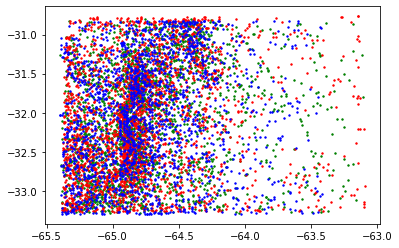

In [9]:
plt.scatter(ds_d3['meanlon'].mean(dim='times'), ds_d3['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4['meanlon'].mean(dim='times'), ds_d4['meanlat'].mean(dim='times'), s=2, c='r')
plt.scatter(ds_d2['meanlon'].mean(dim='times'), ds_d2['meanlat'].mean(dim='times'), s=2, c='b')

In [10]:
minlon_d4 = ds_d4['meanlon'].min().values
maxlon_d4 = ds_d4['meanlon'].max().values
minlat_d4 = ds_d4['meanlat'].min().values
maxlat_d4 = ds_d4['meanlat'].max().values
print(minlon_d4, maxlon_d4, minlat_d4, maxlat_d4)
print(lon_range, lat_range)

-65.38613 -63.093834 -33.269924 -30.764748
[-65.4, -63.1] [-33.3, -30.8]


## Select variables

In [11]:
HAMSL_d2 = ds_d2['z']
time_res_d2 = ds_d2.attrs['time_resolution_hour']
pixel_radius_d2 = ds_d2.attrs['pixel_radius_km']
lifetime_d2 = ds_d2['track_duration'] * time_res_d2

start_time_d2 = ds_d2['start_basetime']
end_time_d2 = ds_d2['end_basetime']
end_merge_tracknumber_d2 = ds_d2['end_merge_tracknumber']
start_split_tracknumber_d2 = ds_d2['start_split_tracknumber']
cell_lon_d2 = ds_d2['cell_meanlon']
cell_lat_d2 = ds_d2['cell_meanlat']

start_lon_d2 = cell_lon_d2.isel(times=0).drop_vars('times')
start_lat_d2 = cell_lat_d2.isel(times=0).drop_vars('times')

In [12]:
HAMSL_d3 = ds_d3['z']
time_res_d3 = ds_d3.attrs['time_resolution_hour']
pixel_radius_d3 = ds_d3.attrs['pixel_radius_km']
lifetime_d3 = ds_d3['track_duration'] * time_res_d3

start_time_d3 = ds_d3['start_basetime']
end_time_d3 = ds_d3['end_basetime']
end_merge_tracknumber_d3 = ds_d3['end_merge_tracknumber']
start_split_tracknumber_d3 = ds_d3['start_split_tracknumber']
cell_lon_d3 = ds_d3['cell_meanlon']
cell_lat_d3 = ds_d3['cell_meanlat']

start_lon_d3 = cell_lon_d3.isel(times=0).drop_vars('times')
start_lat_d3 = cell_lat_d3.isel(times=0).drop_vars('times')

In [13]:
HAMSL_d4 = ds_d4['z']
time_res_d4 = ds_d4.attrs['time_resolution_hour']
pixel_radius_d4 = ds_d4.attrs['pixel_radius_km']
lifetime_d4 = ds_d4['track_duration'] * time_res_d4

start_time_d4 = ds_d4['start_basetime']
end_time_d4 = ds_d4['end_basetime']
end_merge_tracknumber_d4 = ds_d4['end_merge_tracknumber']
start_split_tracknumber_d4 = ds_d4['start_split_tracknumber']
cell_lon_d4 = ds_d4['cell_meanlon']
cell_lat_d4 = ds_d4['cell_meanlat']

start_lon_d4 = cell_lon_d4.isel(times=0).drop_vars('times')
start_lat_d4 = cell_lat_d4.isel(times=0).drop_vars('times')

## Find merge/split tracks

In [14]:
# Find tracks not end with merge or not start with split
nonmerge_d2 = np.where(np.isnan(end_merge_tracknumber_d2))[0]
nonsplit_d2 = np.where(np.isnan(start_split_tracknumber_d2))[0]
ntracks_nonmerge_d2 = len(nonmerge_d2)
ntracks_nonsplit_d2 = len(nonsplit_d2)
print(f'Number of non-merge tracks (D2): {ntracks_nonmerge_d2}')
print(f'Number of non-split tracks (D2): {ntracks_nonsplit_d2}')

merge_d2 = np.where(end_merge_tracknumber_d2 > 0)[0]
split_d2 = np.where(start_split_tracknumber_d2 > 0)[0]
ntracks_merge_d2 = len(merge_d2)
ntracks_split_d2 = len(split_d2)
print(f'Number of merge tracks (D2): {ntracks_merge_d2}')
print(f'Number of split tracks (D2): {ntracks_split_d2}')

Number of non-merge tracks (D2): 1145
Number of non-split tracks (D2): 1161
Number of merge tracks (D2): 835
Number of split tracks (D2): 819


In [15]:
# Find tracks not end with merge or not start with split
nonmerge_d3 = np.where(np.isnan(end_merge_tracknumber_d3))[0]
nonsplit_d3 = np.where(np.isnan(start_split_tracknumber_d3))[0]
ntracks_nonmerge_d3 = len(nonmerge_d3)
ntracks_nonsplit_d3 = len(nonsplit_d3)
print(f'Number of non-merge tracks (D3): {ntracks_nonmerge_d3}')
print(f'Number of non-split tracks (D3): {ntracks_nonsplit_d3}')

merge_d3 = np.where(end_merge_tracknumber_d3 > 0)[0]
split_d3 = np.where(start_split_tracknumber_d3 > 0)[0]
ntracks_merge_d3 = len(merge_d3)
ntracks_split_d3 = len(split_d3)
print(f'Number of merge tracks (D3): {ntracks_merge_d3}')
print(f'Number of split tracks (D3): {ntracks_split_d3}')

Number of non-merge tracks (D3): 1581
Number of non-split tracks (D3): 1556
Number of merge tracks (D3): 978
Number of split tracks (D3): 1003


In [16]:
# Find tracks not end with merge or not start with split
nonmerge_d4 = np.where(np.isnan(end_merge_tracknumber_d4))[0]
nonsplit_d4 = np.where(np.isnan(start_split_tracknumber_d4))[0]
ntracks_nonmerge_d4 = len(nonmerge_d4)
ntracks_nonsplit_d4 = len(nonsplit_d4)
print(f'Number of non-merge tracks (D4): {ntracks_nonmerge_d4}')
print(f'Number of non-split tracks (D4): {ntracks_nonsplit_d4}')

merge_d4 = np.where(end_merge_tracknumber_d4 > 0)[0]
split_d4 = np.where(start_split_tracknumber_d4 > 0)[0]
ntracks_merge_d4 = len(merge_d4)
ntracks_split_d4 = len(split_d4)
print(f'Number of merge tracks (D4): {ntracks_merge_d4}')
print(f'Number of split tracks (D4): {ntracks_split_d4}')

Number of non-merge tracks (D4): 1522
Number of non-split tracks (D4): 1579
Number of merge tracks (D4): 895
Number of split tracks (D4): 838


## Function to calculate quantiles

In [17]:
def quantiles_by1cond(in_var, cond_var, cond_range, loc_var, loc_range, 
                      merge_tracknumber, split_tracknumber, quantiles, 
                      fillval=np.NaN, maxdim=('times','core','z'), 
                      nsdim=('tracks','core'), ns_min=10):
    """
    Calculate quantiles
    """
    # Find max value for each track (over all dimensions)
    max_tracks = in_var.max(dim=maxdim)
    # Subset tracks where max value is not NaN
    trackidx = ~np.isnan(max_tracks)
    in_var = in_var.isel(tracks=trackidx)
    loc_var = loc_var.isel(tracks=trackidx)
    cond_var = cond_var.isel(tracks=trackidx)
    merge_tracknumber = merge_tracknumber.isel(tracks=trackidx)
    split_tracknumber = split_tracknumber.isel(tracks=trackidx)
    
    # Filter tracks with conditions
    in_var_cond = in_var.where((loc_var >= loc_range[0]) & (loc_var <= loc_range[1]) &
                               (cond_var > cond_range[0]) & (cond_var <= cond_range[1]) & 
                               (np.isnan(split_tracknumber)), drop=True)

    nsamples = in_var_cond.sizes['tracks']
       
    # Replace NaN with a large negative value to take into account decreasing sample with height
    # NaN is excluded in quantile calculations which biases the sampling with increasing height
    # fillval = 0
    in_var_cond = in_var_cond.where(~np.isnan(in_var_cond), other=fillval)

    # Calculate initiation quantiles
    out_var_time0_pts = in_var_cond.chunk(dict(tracks=-1)).isel(times=0).quantile(quantiles, dim='tracks', skipna=True)
    # Count initiation valid sample profile
    ns_z = (~np.isnan(in_var_cond.chunk(dict(tracks=-1)).isel(times=0))).sum(dim=nsdim)
    # Filter output variable where sample size is too small
    out_var_time0_pts = out_var_time0_pts.where(ns_z >= ns_min).load()
    
    # Calculate max during lifetime quantiles
    out_var_max_pts = in_var_cond.chunk(dict(tracks=-1)).max(dim='times').quantile(quantiles, dim='tracks', skipna=True)
    # Count max valid sample profile
    ns_z = (~np.isnan(in_var_cond.chunk(dict(tracks=-1)).max(dim='times'))).sum(dim=nsdim)
    # Filter output variable where sample size is too small
    out_var_max_pts = out_var_max_pts.where(ns_z >= ns_min).load()
    
    return (nsamples, out_var_time0_pts, out_var_max_pts)

In [67]:
# Get initiation and lifetime-max profile
lifetime_range1 = [0.4,0.5]
lifetime_range2 = [0.9,1.25]
lifetime_range3 = [1.7,2.25]
lifetime_range4 = [2.25,3.5]

# quantiles_3d = [0.25,0.5,0.75]
quantiles_3d = [0.25,0.5,0.75,0.9,0.95]

lon_SDC = -65
lon_eSDC = [-65, -63]

In [68]:
# ds_d2.CoreArea_up.sel(tracks=35, core=0).sel(times=slice(0,10)).plot()

In [69]:
# ds_d2.CoreArea_up.sel(tracks=35, core=0).sel(times=slice(0,10)).load().data[0,:]

In [70]:

# max_tracks = ds_d2.CoreArea_up.max(dim=('times','core','z'))
# trackidx = ~np.isnan(max_tracks)

# var = ds_d2.CoreArea_up.isel(tracks=trackidx)
# var_cond = var.where(
#     (lifetime_d2 >= 0.4) & (lifetime_d2 <= 0.5) &
#     (start_lon_d2 > -65) & (start_lon_d2 < -63) &
#     (np.isnan(start_split_tracknumber_d2)), drop=True,
# )
# # var_cond = var_cond.where(~np.isnan(), other=np.NaN)
# # tmp.chunk(dict(tracks=-1)).isel(times=0).median(dim='tracks').sel(core=0).plot()
# # # np.count_nonzero(~np.isnan(max_times))
# # # np.count_nonzero(~np.isnan())

In [71]:
# quantiles = [0.25, 0.5, 0.75]
# var_pts = var_cond.chunk(dict(tracks=-1)).isel(times=0).quantile(quantiles, dim='tracks', skipna=True).load()

In [72]:
# ns_z = ((~np.isnan(var_cond.chunk(dict(tracks=-1)).max(dim='times'))).sum(dim=('tracks','core')))
# # ns_z.plot()
# # var_pts.where(ns_z > 5).sel(quantile=0.5).isel(core=0).plot()
# var_pts.where(ns_z > 10).sel(quantile=0.5).mean(dim='core').plot()

In [73]:
# # ((~np.isnan(var_cond.chunk(dict(tracks=-1)).isel(times=0))).sum(dim=('tracks','core'))).plot()
# ((~np.isnan(var_cond.chunk(dict(tracks=-1)).max(dim='times'))).sum(dim=('tracks','core'))).plot()

#### Updraft Max W

In [74]:
# Set min sample size to keep statistics
ns_min = 10
ntracks1_Up_d2, CoreMaxW1_prof0_pts_d2, CoreMaxW1_maxprof_pts_d2 = quantiles_by1cond(ds_d2.CoreMaxW_up, lifetime_d2, lifetime_range1, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks2_Up_d2, CoreMaxW2_prof0_pts_d2, CoreMaxW2_maxprof_pts_d2 = quantiles_by1cond(ds_d2.CoreMaxW_up, lifetime_d2, lifetime_range2, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks3_Up_d2, CoreMaxW3_prof0_pts_d2, CoreMaxW3_maxprof_pts_d2 = quantiles_by1cond(ds_d2.CoreMaxW_up, lifetime_d2, lifetime_range3, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks4_Up_d2, CoreMaxW4_prof0_pts_d2, CoreMaxW4_maxprof_pts_d2 = quantiles_by1cond(ds_d2.CoreMaxW_up, lifetime_d2, lifetime_range4, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
print(f'Number of tracks: {ntracks1_Up_d2}, {ntracks2_Up_d2}, {ntracks3_Up_d2}, {ntracks4_Up_d2}')

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, ax

Number of tracks: 88, 90, 39, 39


/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


In [75]:
# CoreMaxW3_prof0_pts_d3.sel(core=0, quantile=0.5).plot()

In [76]:
ntracks1_Up_d3, CoreMaxW1_prof0_pts_d3, CoreMaxW1_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreMaxW_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks2_Up_d3, CoreMaxW2_prof0_pts_d3, CoreMaxW2_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreMaxW_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks3_Up_d3, CoreMaxW3_prof0_pts_d3, CoreMaxW3_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreMaxW_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks4_Up_d3, CoreMaxW4_prof0_pts_d3, CoreMaxW4_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreMaxW_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
print(f'Number of tracks: {ntracks1_Up_d3}, {ntracks2_Up_d3}, {ntracks3_Up_d3}, {ntracks4_Up_d3}')

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, ax

Number of tracks: 365, 151, 58, 35


/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


In [77]:
# CoreMaxW3_prof0_pts_d3.sel(core=0, quantile=0.5).plot()

In [78]:
ntracks1_Up_d4, CoreMaxW1_prof0_pts_d4, CoreMaxW1_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreMaxW_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks2_Up_d4, CoreMaxW2_prof0_pts_d4, CoreMaxW2_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreMaxW_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks3_Up_d4, CoreMaxW3_prof0_pts_d4, CoreMaxW3_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreMaxW_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks4_Up_d4, CoreMaxW4_prof0_pts_d4, CoreMaxW4_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreMaxW_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
print(f'Number of tracks: {ntracks1_Up_d4}, {ntracks2_Up_d4}, {ntracks3_Up_d4}, {ntracks4_Up_d4}')

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, ax

Number of tracks: 373, 164, 39, 25


/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


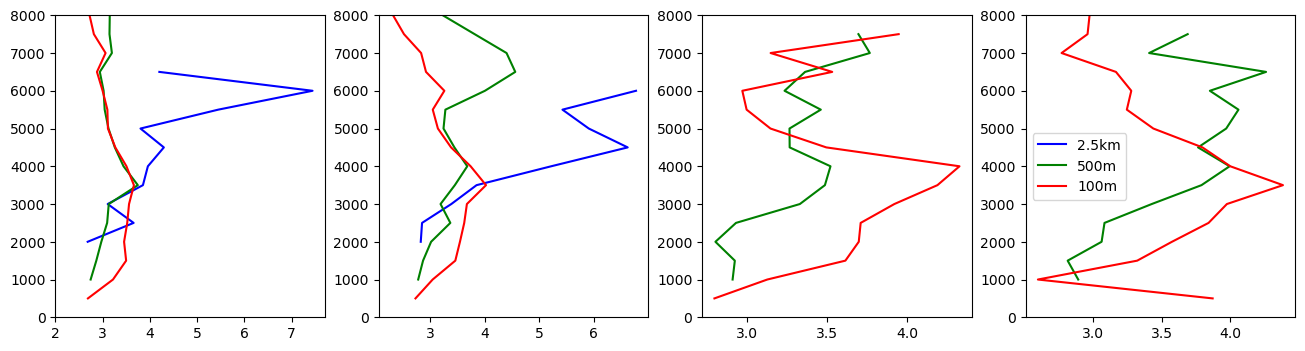

In [79]:
qntl = 0.5
fig, axes = plt.subplots(1,4,figsize=[16,4],dpi=100)
ax = axes[0]
ax.plot(CoreMaxW1_prof0_pts_d2.mean(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreMaxW1_prof0_pts_d3.mean(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreMaxW1_prof0_pts_d4.mean(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,8000)
ax = axes[1]
ax.plot(CoreMaxW2_prof0_pts_d2.mean(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreMaxW2_prof0_pts_d3.mean(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreMaxW2_prof0_pts_d4.mean(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,8000)
ax = axes[2]
ax.plot(CoreMaxW3_prof0_pts_d2.mean(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreMaxW3_prof0_pts_d3.mean(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreMaxW3_prof0_pts_d4.mean(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,8000)
ax = axes[3]
ax.plot(CoreMaxW4_prof0_pts_d2.mean(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreMaxW4_prof0_pts_d3.mean(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreMaxW4_prof0_pts_d4.mean(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,8000)
ax.legend()

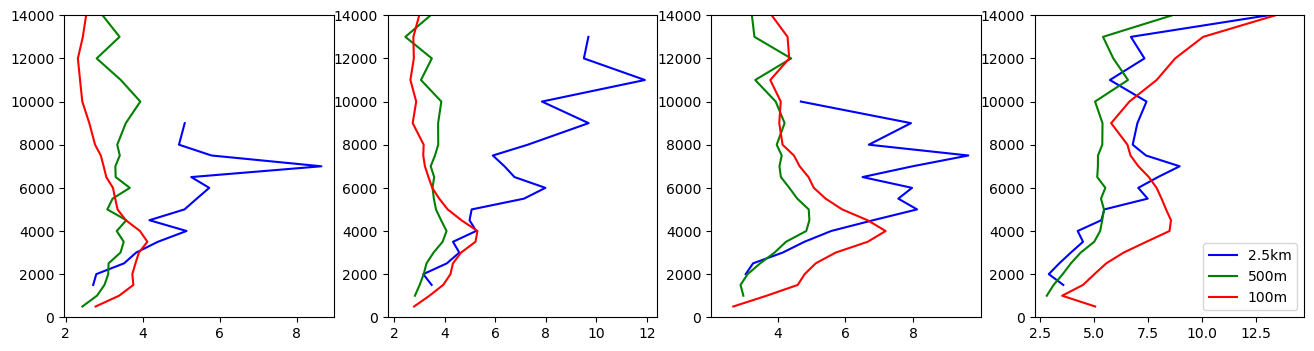

In [80]:
qntl = 0.5
fig, axes = plt.subplots(1,4,figsize=[16,4],dpi=100)
ax = axes[0]
ax.plot(CoreMaxW1_maxprof_pts_d2.mean(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreMaxW1_maxprof_pts_d3.mean(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreMaxW1_maxprof_pts_d4.mean(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,14000)
ax = axes[1]
ax.plot(CoreMaxW2_maxprof_pts_d2.mean(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreMaxW2_maxprof_pts_d3.mean(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreMaxW2_maxprof_pts_d4.mean(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,14000)
ax = axes[2]
ax.plot(CoreMaxW3_maxprof_pts_d2.mean(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreMaxW3_maxprof_pts_d3.mean(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreMaxW3_maxprof_pts_d4.mean(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,14000)
ax = axes[3]
ax.plot(CoreMaxW4_maxprof_pts_d2.mean(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreMaxW4_maxprof_pts_d3.mean(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreMaxW4_maxprof_pts_d4.mean(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,14000)
ax.legend()

#### Updraft mean W

In [81]:
ntracks1_Up_d2, CoreMeanW1_prof0_pts_d2, CoreMeanW1_maxprof_pts_d2 = quantiles_by1cond(ds_d2.CoreMeanW_up, lifetime_d2, lifetime_range1, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks2_Up_d2, CoreMeanW2_prof0_pts_d2, CoreMeanW2_maxprof_pts_d2 = quantiles_by1cond(ds_d2.CoreMeanW_up, lifetime_d2, lifetime_range2, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks3_Up_d2, CoreMeanW3_prof0_pts_d2, CoreMeanW3_maxprof_pts_d2 = quantiles_by1cond(ds_d2.CoreMeanW_up, lifetime_d2, lifetime_range3, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks4_Up_d2, CoreMeanW4_prof0_pts_d2, CoreMeanW4_maxprof_pts_d2 = quantiles_by1cond(ds_d2.CoreMeanW_up, lifetime_d2, lifetime_range4, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, ax

In [82]:
ntracks1_Up_d3, CoreMeanW1_prof0_pts_d3, CoreMeanW1_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreMeanW_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks2_Up_d3, CoreMeanW2_prof0_pts_d3, CoreMeanW2_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreMeanW_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks3_Up_d3, CoreMeanW3_prof0_pts_d3, CoreMeanW3_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreMeanW_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks4_Up_d3, CoreMeanW4_prof0_pts_d3, CoreMeanW4_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreMeanW_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, ax

In [83]:
ntracks1_Up_d4, CoreMeanW1_prof0_pts_d4, CoreMeanW1_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreMeanW_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks2_Up_d4, CoreMeanW2_prof0_pts_d4, CoreMeanW2_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreMeanW_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks3_Up_d4, CoreMeanW3_prof0_pts_d4, CoreMeanW3_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreMeanW_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks4_Up_d4, CoreMeanW4_prof0_pts_d4, CoreMeanW4_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreMeanW_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, ax

(0.0, 12000.0)

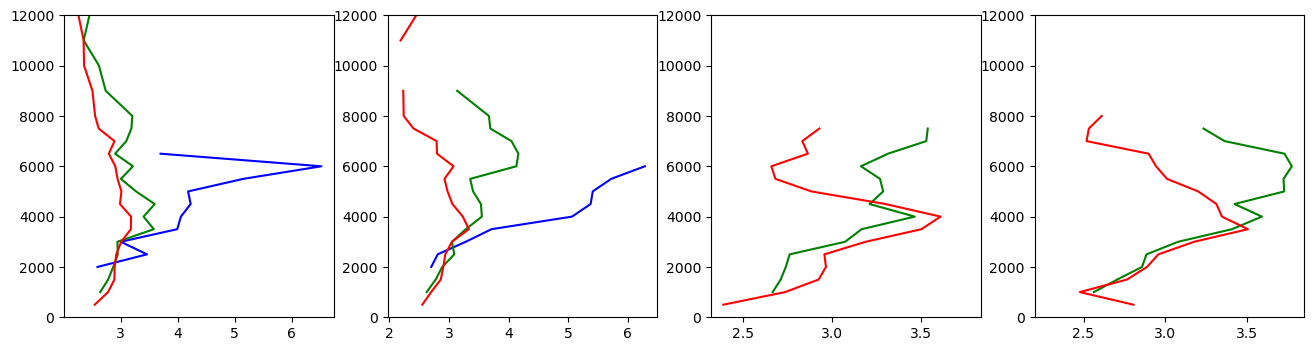

In [84]:
qntl = 0.75
fig, axes = plt.subplots(1,4,figsize=[16,4],dpi=100)
ax = axes[0]
ax.plot(CoreMeanW1_prof0_pts_d2.mean(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreMeanW1_prof0_pts_d3.mean(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreMeanW1_prof0_pts_d4.mean(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,12000)
ax = axes[1]
ax.plot(CoreMeanW2_prof0_pts_d2.mean(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreMeanW2_prof0_pts_d3.mean(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreMeanW2_prof0_pts_d4.mean(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,12000)
ax = axes[2]
ax.plot(CoreMeanW3_prof0_pts_d2.mean(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreMeanW3_prof0_pts_d3.mean(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreMeanW3_prof0_pts_d4.mean(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,12000)
ax = axes[3]
ax.plot(CoreMeanW4_prof0_pts_d2.mean(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreMeanW4_prof0_pts_d3.mean(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreMeanW4_prof0_pts_d4.mean(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,12000)

(0.0, 15000.0)

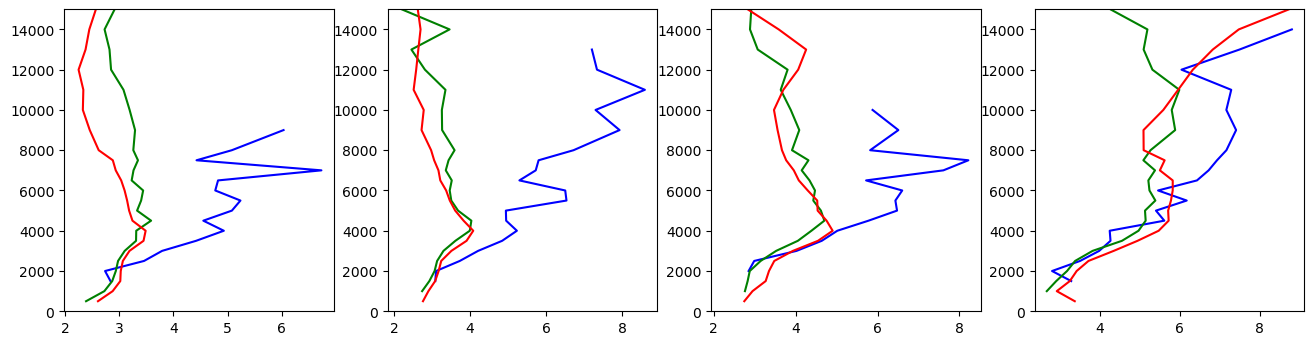

In [85]:
qntl = 0.75
fig, axes = plt.subplots(1,4,figsize=[16,4],dpi=100)
ax = axes[0]
ax.plot(CoreMeanW1_maxprof_pts_d2.mean(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreMeanW1_maxprof_pts_d3.mean(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreMeanW1_maxprof_pts_d4.mean(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax = axes[1]
ax.plot(CoreMeanW2_maxprof_pts_d2.mean(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreMeanW2_maxprof_pts_d3.mean(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreMeanW2_maxprof_pts_d4.mean(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax = axes[2]
ax.plot(CoreMeanW3_maxprof_pts_d2.mean(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreMeanW3_maxprof_pts_d3.mean(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreMeanW3_maxprof_pts_d4.mean(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax = axes[3]
ax.plot(CoreMeanW4_maxprof_pts_d2.mean(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreMeanW4_maxprof_pts_d3.mean(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreMeanW4_maxprof_pts_d4.mean(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)

#### Updraft core area

In [86]:
ntracks1_Up_d2, CoreAreaUp1_prof0_pts_d2, CoreAreaUp1_maxprof_pts_d2 = quantiles_by1cond(ds_d2.CoreArea_up, lifetime_d2, lifetime_range1, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks2_Up_d2, CoreAreaUp2_prof0_pts_d2, CoreAreaUp2_maxprof_pts_d2 = quantiles_by1cond(ds_d2.CoreArea_up, lifetime_d2, lifetime_range2, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks3_Up_d2, CoreAreaUp3_prof0_pts_d2, CoreAreaUp3_maxprof_pts_d2 = quantiles_by1cond(ds_d2.CoreArea_up, lifetime_d2, lifetime_range3, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks4_Up_d2, CoreAreaUp4_prof0_pts_d2, CoreAreaUp4_maxprof_pts_d2 = quantiles_by1cond(ds_d2.CoreArea_up, lifetime_d2, lifetime_range4, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, ax

In [87]:
ntracks1_Up_d3, CoreAreaUp1_prof0_pts_d3, CoreAreaUp1_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreArea_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks2_Up_d3, CoreAreaUp2_prof0_pts_d3, CoreAreaUp2_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreArea_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks3_Up_d3, CoreAreaUp3_prof0_pts_d3, CoreAreaUp3_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreArea_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks4_Up_d3, CoreAreaUp4_prof0_pts_d3, CoreAreaUp4_maxprof_pts_d3 = quantiles_by1cond(ds_d3.CoreArea_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, ax

In [88]:
ntracks1_Up_d4, CoreAreaUp1_prof0_pts_d4, CoreAreaUp1_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreArea_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks2_Up_d4, CoreAreaUp2_prof0_pts_d4, CoreAreaUp2_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreArea_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks3_Up_d4, CoreAreaUp3_prof0_pts_d4, CoreAreaUp3_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreArea_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)
ntracks4_Up_d4, CoreAreaUp4_prof0_pts_d4, CoreAreaUp4_maxprof_pts_d4 = quantiles_by1cond(ds_d4.CoreArea_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d, fillval=np.NaN,
                                                                       nsdim=('tracks','core'), ns_min=ns_min)

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, ax

(0.0, 15000.0)

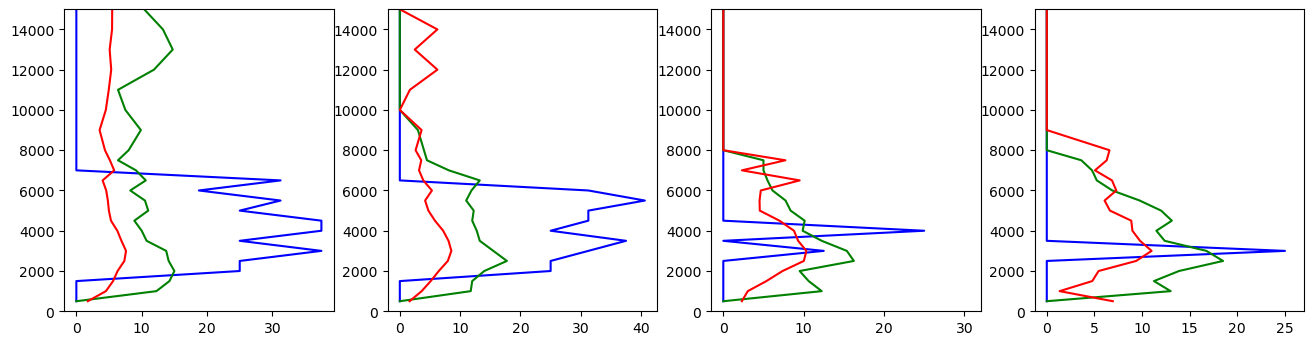

In [89]:
qntl = 0.5
fig, axes = plt.subplots(1,4,figsize=[16,4],dpi=100)
ax = axes[0]
ax.plot(CoreAreaUp1_prof0_pts_d2.sum(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreAreaUp1_prof0_pts_d3.sum(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreAreaUp1_prof0_pts_d4.sum(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax = axes[1]
ax.plot(CoreAreaUp2_prof0_pts_d2.sum(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreAreaUp2_prof0_pts_d3.sum(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreAreaUp2_prof0_pts_d4.sum(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax = axes[2]
ax.plot(CoreAreaUp3_prof0_pts_d2.sum(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreAreaUp3_prof0_pts_d3.sum(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreAreaUp3_prof0_pts_d4.sum(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax = axes[3]
ax.plot(CoreAreaUp4_prof0_pts_d2.sum(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreAreaUp4_prof0_pts_d3.sum(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreAreaUp4_prof0_pts_d4.sum(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)

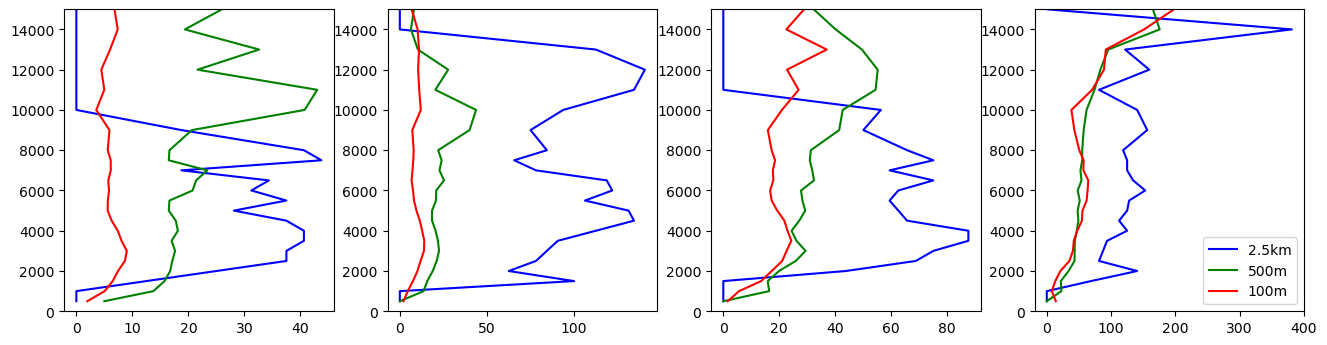

In [90]:
qntl = 0.5
fig, axes = plt.subplots(1,4,figsize=[16,4],dpi=100)
ax = axes[0]
ax.plot(CoreAreaUp1_maxprof_pts_d2.sum(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreAreaUp1_maxprof_pts_d3.sum(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreAreaUp1_maxprof_pts_d4.sum(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax = axes[1]
ax.plot(CoreAreaUp2_maxprof_pts_d2.sum(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreAreaUp2_maxprof_pts_d3.sum(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreAreaUp2_maxprof_pts_d4.sum(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax = axes[2]
ax.plot(CoreAreaUp3_maxprof_pts_d2.sum(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreAreaUp3_maxprof_pts_d3.sum(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreAreaUp3_maxprof_pts_d4.sum(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax = axes[3]
ax.plot(CoreAreaUp4_maxprof_pts_d2.sum(dim='core').sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(CoreAreaUp4_maxprof_pts_d3.sum(dim='core').sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(CoreAreaUp4_maxprof_pts_d4.sum(dim='core').sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax.legend()

#### Number of updraft cores

In [91]:
maxdim = ('times','z')
ntracks1_Up_d2, nCoreUp1_prof0_pts_d2, nCoreUp1_maxprof_pts_d2 = quantiles_by1cond(ds_d2.nCore_up, lifetime_d2, lifetime_range1, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks2_Up_d2, nCoreUp2_prof0_pts_d2, nCoreUp2_maxprof_pts_d2 = quantiles_by1cond(ds_d2.nCore_up, lifetime_d2, lifetime_range2, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks3_Up_d2, nCoreUp3_prof0_pts_d2, nCoreUp3_maxprof_pts_d2 = quantiles_by1cond(ds_d2.nCore_up, lifetime_d2, lifetime_range3, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks4_Up_d2, nCoreUp4_prof0_pts_d2, nCoreUp4_maxprof_pts_d2 = quantiles_by1cond(ds_d2.nCore_up, lifetime_d2, lifetime_range4, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)

In [92]:
ntracks1_Up_d3, nCoreUp1_prof0_pts_d3, nCoreUp1_maxprof_pts_d3 = quantiles_by1cond(ds_d3.nCore_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks2_Up_d3, nCoreUp2_prof0_pts_d3, nCoreUp2_maxprof_pts_d3 = quantiles_by1cond(ds_d3.nCore_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks3_Up_d3, nCoreUp3_prof0_pts_d3, nCoreUp3_maxprof_pts_d3 = quantiles_by1cond(ds_d3.nCore_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks4_Up_d3, nCoreUp4_prof0_pts_d3, nCoreUp4_maxprof_pts_d3 = quantiles_by1cond(ds_d3.nCore_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)

In [93]:
ntracks1_Up_d4, nCoreUp1_prof0_pts_d4, nCoreUp1_maxprof_pts_d4 = quantiles_by1cond(ds_d4.nCore_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks2_Up_d4, nCoreUp2_prof0_pts_d4, nCoreUp2_maxprof_pts_d4 = quantiles_by1cond(ds_d4.nCore_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks3_Up_d4, nCoreUp3_prof0_pts_d4, nCoreUp3_maxprof_pts_d4 = quantiles_by1cond(ds_d4.nCore_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks4_Up_d4, nCoreUp4_prof0_pts_d4, nCoreUp4_maxprof_pts_d4 = quantiles_by1cond(ds_d4.nCore_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)

#### Updrat mass flux

In [94]:
ntracks1_Up_d2, MassFluxUp1_prof0_pts_d2, MassFluxUp1_maxprof_pts_d2 = quantiles_by1cond(ds_d2.MassFlux_up, lifetime_d2, lifetime_range1, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks2_Up_d2, MassFluxUp2_prof0_pts_d2, MassFluxUp2_maxprof_pts_d2 = quantiles_by1cond(ds_d2.MassFlux_up, lifetime_d2, lifetime_range2, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks3_Up_d2, MassFluxUp3_prof0_pts_d2, MassFluxUp3_maxprof_pts_d2 = quantiles_by1cond(ds_d2.MassFlux_up, lifetime_d2, lifetime_range3, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks4_Up_d2, MassFluxUp4_prof0_pts_d2, MassFluxUp4_maxprof_pts_d2 = quantiles_by1cond(ds_d2.MassFlux_up, lifetime_d2, lifetime_range4, start_lon_d2, lon_eSDC,
                                                                       end_merge_tracknumber_d2, start_split_tracknumber_d2, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)

In [95]:
ntracks1_Up_d3, MassFluxUp1_prof0_pts_d3, MassFluxUp1_maxprof_pts_d3 = quantiles_by1cond(ds_d3.MassFlux_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks2_Up_d3, MassFluxUp2_prof0_pts_d3, MassFluxUp2_maxprof_pts_d3 = quantiles_by1cond(ds_d3.MassFlux_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks3_Up_d3, MassFluxUp3_prof0_pts_d3, MassFluxUp3_maxprof_pts_d3 = quantiles_by1cond(ds_d3.MassFlux_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks4_Up_d3, MassFluxUp4_prof0_pts_d3, MassFluxUp4_maxprof_pts_d3 = quantiles_by1cond(ds_d3.MassFlux_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                                       end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)

In [96]:
ntracks1_Up_d4, MassFluxUp1_prof0_pts_d4, MassFluxUp1_maxprof_pts_d4 = quantiles_by1cond(ds_d4.MassFlux_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks2_Up_d4, MassFluxUp2_prof0_pts_d4, MassFluxUp2_maxprof_pts_d4 = quantiles_by1cond(ds_d4.MassFlux_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks3_Up_d4, MassFluxUp3_prof0_pts_d4, MassFluxUp3_maxprof_pts_d4 = quantiles_by1cond(ds_d4.MassFlux_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)
ntracks4_Up_d4, MassFluxUp4_prof0_pts_d4, MassFluxUp4_maxprof_pts_d4 = quantiles_by1cond(ds_d4.MassFlux_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                                       end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_3d, maxdim=maxdim,
                                                                       nsdim=('tracks'), ns_min=ns_min)

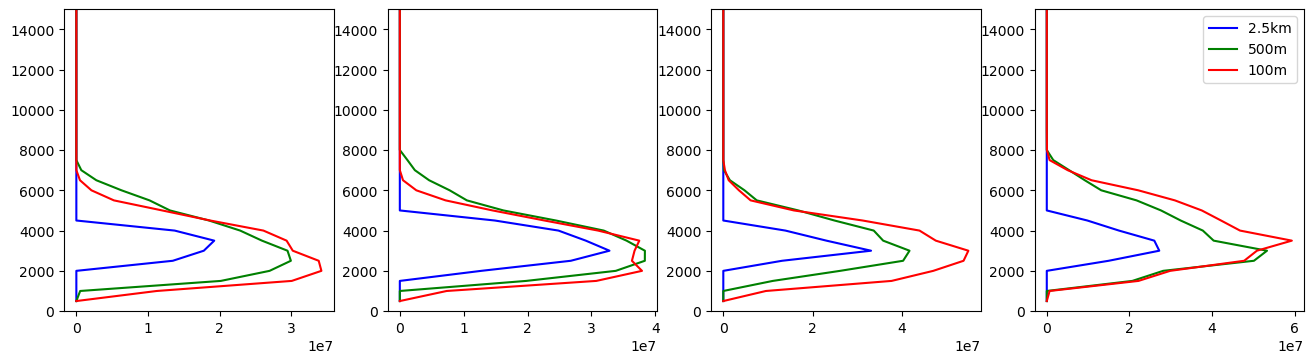

In [97]:
qntl = 0.75
fig, axes = plt.subplots(1,4,figsize=[16,4],dpi=100)
ax = axes[0]
ax.plot(MassFluxUp1_prof0_pts_d2.sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(MassFluxUp1_prof0_pts_d3.sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(MassFluxUp1_prof0_pts_d4.sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax = axes[1]
ax.plot(MassFluxUp2_prof0_pts_d2.sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(MassFluxUp2_prof0_pts_d3.sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(MassFluxUp2_prof0_pts_d4.sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax = axes[2]
ax.plot(MassFluxUp3_prof0_pts_d2.sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(MassFluxUp3_prof0_pts_d3.sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(MassFluxUp3_prof0_pts_d4.sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax = axes[3]
ax.plot(MassFluxUp4_prof0_pts_d2.sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(MassFluxUp4_prof0_pts_d3.sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(MassFluxUp4_prof0_pts_d4.sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax.legend()

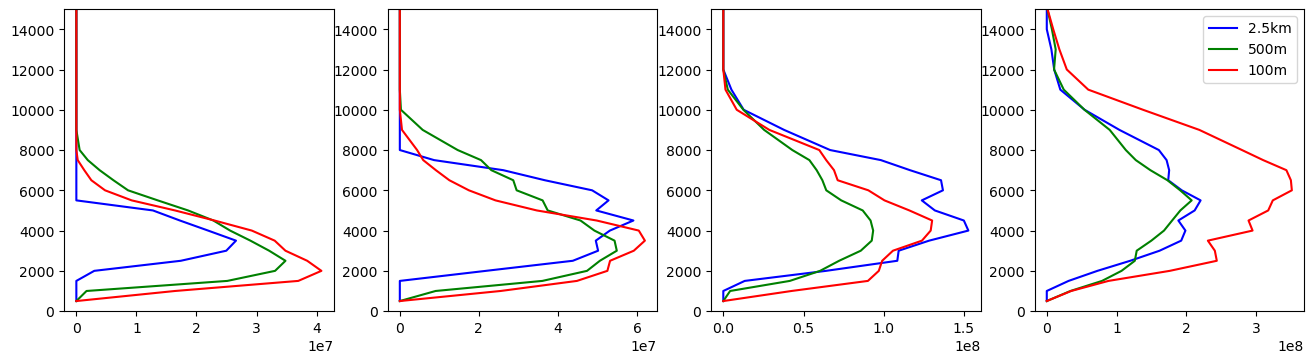

In [98]:
qntl = 0.75
fig, axes = plt.subplots(1,4,figsize=[16,4],dpi=100)
ax = axes[0]
ax.plot(MassFluxUp1_maxprof_pts_d2.sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(MassFluxUp1_maxprof_pts_d3.sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(MassFluxUp1_maxprof_pts_d4.sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax = axes[1]
ax.plot(MassFluxUp2_maxprof_pts_d2.sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(MassFluxUp2_maxprof_pts_d3.sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(MassFluxUp2_maxprof_pts_d4.sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax = axes[2]
ax.plot(MassFluxUp3_maxprof_pts_d2.sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(MassFluxUp3_maxprof_pts_d3.sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(MassFluxUp3_maxprof_pts_d4.sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax = axes[3]
ax.plot(MassFluxUp4_maxprof_pts_d2.sel(quantile=qntl), HAMSL_d2, ls='-', color='b', label='2.5km')
ax.plot(MassFluxUp4_maxprof_pts_d3.sel(quantile=qntl), HAMSL_d3, ls='-', color='g', label='500m')
ax.plot(MassFluxUp4_maxprof_pts_d4.sel(quantile=qntl), HAMSL_d4, ls='-', color='r', label='100m')
ax.set_ylim(0,15000)
ax.legend()

In [99]:
# CoreMeanW1_prof0_pts_d2

In [54]:
print(ntracks1_Up_d2, ntracks1_Up_d3, ntracks1_Up_d4)

228 374 375


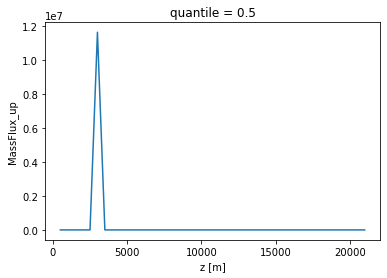

In [52]:
qntl = 0.5
MassFluxUp1_maxprof_pts_d2.sel(quantile=qntl).plot()

In [119]:
# plt.plot(CoreMaxW1_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='b')
# plt.plot(CoreMaxW2_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='g')
# plt.plot(CoreMaxW3_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='orange')
# plt.plot(CoreMaxW4_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='r')
# plt.ylim(0,8000)

In [120]:
# plt.plot(CoreMeanW1_prof0_pts_d3[1,:,0], HAMSL_d3, ls='--', color='b')
# plt.plot(CoreMeanW1_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='b')
# plt.plot(CoreMeanW2_prof0_pts_d3[1,:,0], HAMSL_d3, ls='--', color='g')
# plt.plot(CoreMeanW2_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='g')
# plt.plot(CoreMeanW3_prof0_pts_d3[1,:,0], HAMSL_d3, ls='--', color='r')
# plt.plot(CoreMeanW3_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='r')
# plt.ylim(0,8000)

In [121]:
# plt.plot(CoreMeanW1_maxprof_pts_d3[1,:,0], HAMSL_d3, ls='--', color='b')
# plt.plot(CoreMeanW1_maxprof_pts_d4[1,:,0], HAMSL_d4, ls='-', color='b')
# plt.plot(CoreMeanW2_maxprof_pts_d3[1,:,0], HAMSL_d3, ls='--', color='g')
# plt.plot(CoreMeanW2_maxprof_pts_d4[1,:,0], HAMSL_d4, ls='-', color='g')
# plt.plot(CoreMeanW3_maxprof_pts_d3[1,:,0], HAMSL_d3, ls='--', color='r')
# plt.plot(CoreMeanW3_maxprof_pts_d4[1,:,0], HAMSL_d4, ls='-', color='r')
# plt.ylim(0,12000)

In [122]:
# plt.plot(CoreAreaUp1_prof0_pts_d2[1,:,0], HAMSL_d2, ls='-', color='b')
# plt.plot(CoreAreaUp1_prof0_pts_d3[1,:,0], HAMSL_d3, ls='-', color='g')
# plt.plot(CoreAreaUp1_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='r')
# # plt.plot(CoreAreaUp1_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='r')
# plt.ylim(0,12000)

In [123]:
# plt.plot(CoreAreaUp1_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='b')
# plt.plot(CoreAreaUp2_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='g')
# plt.plot(CoreAreaUp3_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='orange')
# plt.plot(CoreAreaUp4_prof0_pts_d3[1,:,0], HAMSL_d4, ls='-', color='r')
# plt.ylim(0,8000)

In [124]:
# plt.plot(CoreAreaUp1_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='b')
# plt.plot(CoreAreaUp2_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='g')
# plt.plot(CoreAreaUp3_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='orange')
# plt.plot(CoreAreaUp4_prof0_pts_d4[1,:,0], HAMSL_d4, ls='-', color='r')
# plt.ylim(0,8000)

In [125]:
# plt.plot(MassFluxUp1_prof0_pts_d3[1,:], HAMSL_d4, ls='-', color='b')
# plt.plot(MassFluxUp2_prof0_pts_d3[1,:], HAMSL_d4, ls='-', color='g')
# plt.plot(MassFluxUp3_prof0_pts_d3[1,:], HAMSL_d4, ls='-', color='orange')
# plt.plot(MassFluxUp4_prof0_pts_d3[1,:], HAMSL_d4, ls='-', color='r')
# plt.ylim(0,8000)

In [126]:
# plt.plot(MassFluxUp1_prof0_pts_d4[1,:], HAMSL_d4, ls='-', color='b')
# plt.plot(MassFluxUp2_prof0_pts_d4[1,:], HAMSL_d4, ls='-', color='g')
# plt.plot(MassFluxUp3_prof0_pts_d4[1,:], HAMSL_d4, ls='-', color='orange')
# plt.plot(MassFluxUp4_prof0_pts_d4[1,:], HAMSL_d4, ls='-', color='r')
# plt.ylim(0,8000)

In [51]:
# plt.plot(nCoreUp1_maxprof_pts_d3[1,:], HAMSL_d3, ls='--', color='b')
# plt.plot(nCoreUp2_maxprof_pts_d3[1,:], HAMSL_d3, ls='--', color='g')
# plt.plot(nCoreUp3_maxprof_pts_d3[1,:], HAMSL_d3, ls='--', color='orange')
# plt.plot(nCoreUp4_maxprof_pts_d3[1,:], HAMSL_d3, ls='--', color='r')
# plt.plot(nCoreUp1_maxprof_pts_d4[1,:], HAMSL_d4, ls='-', color='b')
# plt.plot(nCoreUp2_maxprof_pts_d4[1,:], HAMSL_d4, ls='-', color='g')
# plt.plot(nCoreUp3_maxprof_pts_d4[1,:], HAMSL_d4, ls='-', color='orange')
# plt.plot(nCoreUp4_maxprof_pts_d4[1,:], HAMSL_d4, ls='-', color='r')
# plt.ylim(0,15000)

In [52]:
# plt.plot(CoreMaxW1_prof0_pts_d3[1,:,0], HAMSL_d3, ls='--', color='b')
# plt.plot(CoreMaxW2_prof0_pts_d3[1,:,0], HAMSL_d3, ls='--', color='g')
# plt.plot(CoreMaxW3_prof0_pts_d3[1,:,0], HAMSL_d3, ls='--', color='orange')
# plt.plot(CoreMaxW4_prof0_pts_d3[1,:,0], HAMSL_d3, ls='--', color='r')
# plt.plot(CoreMaxW1_prof0_pts_d4[1,:,0], HAMSL_d4, color='b')
# plt.plot(CoreMaxW2_prof0_pts_d4[1,:,0], HAMSL_d4, color='g')
# plt.plot(CoreMaxW3_prof0_pts_d4[1,:,0], HAMSL_d4, color='orange')
# plt.plot(CoreMaxW4_prof0_pts_d4[1,:,0], HAMSL_d4, color='r')
# plt.ylim(0,7000)

In [53]:
# plt.plot(CoreMaxW1_maxprof_pts_d3[1,:,0], HAMSL_d3, ls='--', color='b')
# plt.plot(CoreMaxW2_maxprof_pts_d3[1,:,0], HAMSL_d3, ls='--', color='g')
# plt.plot(CoreMaxW3_maxprof_pts_d3[1,:,0], HAMSL_d3, ls='--', color='orange')
# plt.plot(CoreMaxW4_maxprof_pts_d3[1,:,0], HAMSL_d3, ls='--', color='r')
# plt.plot(CoreMaxW1_maxprof_pts_d4[1,:,0], HAMSL_d4, ls='-', color='b')
# plt.plot(CoreMaxW2_maxprof_pts_d4[1,:,0], HAMSL_d4, ls='-', color='g')
# plt.plot(CoreMaxW3_maxprof_pts_d4[1,:,0], HAMSL_d4, ls='-', color='orange')
# plt.plot(CoreMaxW4_maxprof_pts_d4[1,:,0], HAMSL_d4, ls='-', color='r')
# plt.ylim(0,15000)

In [54]:
def plot_profiles_NxM(data1_avg, data2_avg, data3_avg, data1_pts, data2_pts, data3_pts, height, xlims, ylims, xlabels, titles1, titles2, legends, figname, 
                      figsize=(10, 10), fontsize=14, nrow=1, ncol=1):
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['figure.facecolor'] = 'white'
    # nrow = len(data1_avg)
    # ncol = len(data1_avg[0])
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, dpi=300)

    # ylims = [1, 15]
    colors = {'low':'blue', 'medium':'green', 'high':'crimson'}
    
    for row in range(nrow):
        for col in range(ncol):
            if nrow == 1:
                ax = axes[col]
            else:
                ax = axes[row, col]
            ax.plot(data1_avg[row][col], height, color=colors['low'], lw=5, label=legends[0])
            ax.plot(data2_avg[row][col], height, color=colors['medium'], lw=5, label=legends[1])
            ax.plot(data3_avg[row][col], height, color=colors['high'], lw=5, label=legends[2])
            # Replace left fill values with -99 if right fill value is not inf
            fill1 = [data1_pts[row][col][0], data1_pts[row][col][1]]
            fill2 = [data2_pts[row][col][0], data2_pts[row][col][1]]
            fill3 = [data3_pts[row][col][0], data3_pts[row][col][1]]
            idx1 = np.where((np.isinf(fill1[0]) & ~np.isinf(fill1[1])))
            idx2 = np.where((np.isinf(fill2[0]) & ~np.isinf(fill2[1])))
            idx3 = np.where((np.isinf(fill3[0]) & ~np.isinf(fill3[1])))
            fill1[0][idx1] = -99
            fill2[0][idx2] = -99
            fill3[0][idx3] = -99
            ax.fill_betweenx(height, fill1[0], fill1[1], color=colors['low'], edgecolor=None, alpha=0.25)
            ax.fill_betweenx(height, fill2[0], fill2[1], color=colors['medium'], edgecolor=None, alpha=0.25)
            ax.fill_betweenx(height, fill3[0], fill3[1], color=colors['high'], edgecolor=None, alpha=0.25)
#             ax.fill_betweenx(height, data1_pts[row][col][0], data1_pts[row][col][1], color=colors['low'], edgecolor=None, alpha=0.25)
#             ax.fill_betweenx(height, data2_pts[row][col][0], data2_pts[row][col][1], color=colors['medium'], edgecolor=None, alpha=0.25)
#             ax.fill_betweenx(height, data3_pts[row][col][0], data3_pts[row][col][1], color=colors['high'], edgecolor=None, alpha=0.25)
            ax.grid(ls='--')
            ax.set_xlim(xlims[row][col][0], xlims[row][col][1])
            ax.set_ylim(ylims[0], ylims[1])
            ax.set_xlabel(xlabels[row][col])
            ax.set_ylabel('Height ASL (km)')
            ax.set_title(titles1[row][col], loc='left')
            ax.set_title(titles2, loc='right', fontsize=14)
            if (row == 0) & (col == 0):
                ax.legend(loc='upper right', fontsize=12)
    
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

In [ ]:
MFpower = 7
MFscale = 10**MFpower

data1_avg = [
    [CoreAreaUp1_prof0_pts_d3.sel(quantile=0.5).isel(core=0), 
     CoreMaxW1_prof0_pts_d3.sel(quantile=0.5).isel(core=0), 
     nCoreUp1_prof0_pts_d3.sel(quantile=0.5), 
     MassFluxUp1_prof0_pts_d3.sel(quantile=0.5)/MFscale],
    [],
]
data2_avg = [
    [CoreAreaUp2_prof0_pts_d3.sel(quantile=0.5).isel(core=0), 
     CoreMaxW2_prof0_pts_d3.sel(quantile=0.5).isel(core=0), 
     nCoreUp2_prof0_pts_d3.sel(quantile=0.5), 
     MassFluxUp2_prof0_pts_d3.sel(quantile=0.5)/MFscale],
    [],
]
data3_avg = [
    [CoreAreaUp3_prof0_pts_d3.sel(quantile=0.5).isel(core=0), 
     CoreMaxW3_prof0_pts_d3.sel(quantile=0.5).isel(core=0), 
     nCoreUp3_prof0_pts_d3.sel(quantile=0.5), 
     MassFluxUp3_prof0_pts_d3.sel(quantile=0.5)/MFscale],
    [],
]
data1_pts = [
    [(CoreAreaUp1_prof0_pts_d3.sel(quantile=0.25).isel(core=0), CoreAreaUp1_prof0_pts_d3.sel(quantile=0.75).isel(core=0)),
     (CoreMaxW1_prof0_pts_d3.sel(quantile=0.25).isel(core=0), CoreMaxW1_prof0_pts_d3.sel(quantile=0.75).isel(core=0)),
     (nCoreUp1_prof0_pts_d3.sel(quantile=0.25), nCoreUp1_prof0_pts_d3.sel(quantile=0.75)),
     (MassFluxUp1_prof0_pts_d3.sel(quantile=0.25)/MFscale, MassFluxUp1_prof0_pts_d3.sel(quantile=0.75)/MFscale)],
    [],
]
data2_pts = [
    [(CoreAreaUp2_prof0_pts_d3.sel(quantile=0.25).isel(core=0), CoreAreaUp2_prof0_pts_d3.sel(quantile=0.75).isel(core=0)),
     (CoreMaxW2_prof0_pts_d3.sel(quantile=0.25).isel(core=0), CoreMaxW2_prof0_pts_d3.sel(quantile=0.75).isel(core=0)),
     (nCoreUp2_prof0_pts_d3.sel(quantile=0.25), nCoreUp2_prof0_pts_d3.sel(quantile=0.75)),
     (MassFluxUp2_prof0_pts_d3.sel(quantile=0.25)/MFscale, MassFluxUp2_prof0_pts_d3.sel(quantile=0.75)/MFscale)],
    [],
]
data3_pts = [
    [(CoreAreaUp3_prof0_pts_d3.sel(quantile=0.25).isel(core=0), CoreAreaUp3_prof0_pts_d3.sel(quantile=0.75).isel(core=0)),
     (CoreMaxW3_prof0_pts_d3.sel(quantile=0.25).isel(core=0), CoreMaxW3_prof0_pts_d3.sel(quantile=0.75).isel(core=0)),
     (nCoreUp3_prof0_pts_d3.sel(quantile=0.25), nCoreUp3_prof0_pts_d3.sel(quantile=0.75)),
     (MassFluxUp3_prof0_pts_d3.sel(quantile=0.25)/MFscale, MassFluxUp3_prof0_pts_d3.sel(quantile=0.75)/MFscale)],
    [],
]
xlims = [[(0,6), (0,10), (0,10), (0, 5)]]
ylims = (0, 8)
xlabels = [['Core Area (km$^2$)', 'Max W (m s$^{-1}$)', 'Number of Cores', f'Core Mass Flux (x10$^{MFpower}$ kg s$^{-1}$)']]
figname = f'{figdir}cell_initiation_w_profiles_d3.png'
titles1 = [['(a) Core Area (500m)', '(b) Max W (500m)', '(c) NCores (500m)', '(d) Mass Flux (500m)']]
titles2 = '(CI)'
legends = [f'{lifetime_range1[0]}-{lifetime_range1[1]} hr ({ntracks1_Up_d3})',
           f'{lifetime_range2[0]}-{lifetime_range2[1]} hr ({ntracks2_Up_d3})',
           f'{lifetime_range3[0]}-{lifetime_range3[1]} hr ({ntracks3_Up_d3})',]
figsize = (16, 6)
fontsize = 14
fig = plot_profiles_NxM(data1_avg, data2_avg, data3_avg, data1_pts, data2_pts, data3_pts, HAMSL_d3/1000, xlims, ylims, xlabels, titles1, titles2, legends, figname, 
                        figsize=figsize, fontsize=fontsize, nrow=1, ncol=4)

In [ ]:
data1_avg = [
    [CoreAreaUp1_prof0_pts_d4.sel(quantile=0.5).isel(core=0), 
     CoreMaxW1_prof0_pts_d4.sel(quantile=0.5).isel(core=0), 
     nCoreUp1_prof0_pts_d4.sel(quantile=0.5), 
     MassFluxUp1_prof0_pts_d4.sel(quantile=0.5)/MFscale],
    [],
]
data2_avg = [
    [CoreAreaUp2_prof0_pts_d4.sel(quantile=0.5).isel(core=0), 
     CoreMaxW2_prof0_pts_d4.sel(quantile=0.5).isel(core=0), 
     nCoreUp2_prof0_pts_d4.sel(quantile=0.5), 
     MassFluxUp2_prof0_pts_d4.sel(quantile=0.5)/MFscale],
    [],
]
data3_avg = [
    [CoreAreaUp3_prof0_pts_d4.sel(quantile=0.5).isel(core=0), 
     CoreMaxW3_prof0_pts_d4.sel(quantile=0.5).isel(core=0), 
     nCoreUp3_prof0_pts_d4.sel(quantile=0.5), 
     MassFluxUp3_prof0_pts_d4.sel(quantile=0.5)/MFscale],
    [],
]
data1_pts = [
    [(CoreAreaUp1_prof0_pts_d4.sel(quantile=0.25).isel(core=0), CoreAreaUp1_prof0_pts_d4.sel(quantile=0.75).isel(core=0)),
     (CoreMaxW1_prof0_pts_d4.sel(quantile=0.25).isel(core=0), CoreMaxW1_prof0_pts_d4.sel(quantile=0.75).isel(core=0)),
     (nCoreUp1_prof0_pts_d4.sel(quantile=0.25), nCoreUp1_prof0_pts_d4.sel(quantile=0.75)),
     (MassFluxUp1_prof0_pts_d4.sel(quantile=0.25)/MFscale, MassFluxUp1_prof0_pts_d4.sel(quantile=0.75)/MFscale)],
    [],
]
data2_pts = [
    [(CoreAreaUp2_prof0_pts_d4.sel(quantile=0.25).isel(core=0), CoreAreaUp2_prof0_pts_d4.sel(quantile=0.75).isel(core=0)),
     (CoreMaxW2_prof0_pts_d4.sel(quantile=0.25).isel(core=0), CoreMaxW2_prof0_pts_d4.sel(quantile=0.75).isel(core=0)),
     (nCoreUp2_prof0_pts_d4.sel(quantile=0.25), nCoreUp2_prof0_pts_d4.sel(quantile=0.75)),
     (MassFluxUp2_prof0_pts_d4.sel(quantile=0.25)/MFscale, MassFluxUp2_prof0_pts_d4.sel(quantile=0.75)/MFscale)],
    [],
]
data3_pts = [
    [(CoreAreaUp3_prof0_pts_d4.sel(quantile=0.25).isel(core=0), CoreAreaUp3_prof0_pts_d4.sel(quantile=0.75).isel(core=0)),
     (CoreMaxW3_prof0_pts_d4.sel(quantile=0.25).isel(core=0), CoreMaxW3_prof0_pts_d4.sel(quantile=0.75).isel(core=0)),
     (nCoreUp3_prof0_pts_d4.sel(quantile=0.25), nCoreUp3_prof0_pts_d4.sel(quantile=0.75)),
     (MassFluxUp3_prof0_pts_d4.sel(quantile=0.25)/MFscale, MassFluxUp3_prof0_pts_d4.sel(quantile=0.75)/MFscale)],
    [],
]
xlims = [[(0,6), (0,10), (0,80), (0, 5)]]
ylims = (0, 8)
xlabels = [['Core Area () (km$^2$)', 'Max W (m s$^{-1}$)', 'Number of Cores', f'Core Mass Flux (x10$^{MFpower}$ kg s$^{-1}$)']]
figname = f'{figdir}cell_initiation_w_profiles_d4.png'
titles1 = [['(a) Core Area (100m)', '(b) Max W (100m)', '(c) NCores (100m)', '(d) Mass Flux (100m)']]
titles2 = '(CI)'
legends = [f'{lifetime_range1[0]}-{lifetime_range1[1]} hr ({ntracks1_Up_d4})',
           f'{lifetime_range2[0]}-{lifetime_range2[1]} hr ({ntracks2_Up_d4})',
           f'{lifetime_range3[0]}-{lifetime_range3[1]} hr ({ntracks3_Up_d4})',]
figsize = (16, 6)
fontsize = 14
fig = plot_profiles_NxM(data1_avg, data2_avg, data3_avg, data1_pts, data2_pts, data3_pts, HAMSL_d4/1000, xlims, ylims, xlabels, titles1, titles2, legends, figname, 
                        figsize=figsize, fontsize=fontsize, nrow=1, ncol=4)

In [ ]:
figdir

# Composite updraft core time-series profiles by lifetime

In [ ]:
def quantiles_time_by1cond(in_var, cond1_var, cond1_range, loc_var, loc_range, merge_tracknumber, split_tracknumber, quantiles, fillval=-99):
    in_var_cond = in_var.where((loc_var >= loc_range[0]) & (loc_var <= loc_range[1]) &
                                (cond1_var > cond1_range[0]) & (cond1_var <= cond1_range[1]) & 
                                (np.isnan(merge_tracknumber)) & (np.isnan(split_tracknumber)), drop=True)

    nsamples = in_var_cond.sizes['tracks']
    
    # Replace NaN with a fill value to take into account decreasing sample with height
    # NaN is excluded in quantile calculations which biases the sampling with increasing height
    in_var_cond = in_var_cond.where(~np.isnan(in_var_cond), other=fillval)
    
    # Get time-series quantile
    out_var_cond_pts = in_var_cond.chunk(dict(tracks=-1)).quantile(quantiles, dim='tracks', skipna=True).load()
    
    return (nsamples, out_var_cond_pts)

In [ ]:
# Get initiation and lifetime-max profile
lifetime_range1 = [0.4,0.5]
lifetime_range2 = [0.9,1.25]
lifetime_range3 = [1.7,2.25]
lifetime_range4 = [2.25,3.5]

lon_SDC = -65
lon_eSDC = [-65, -63]

quantiles_timeseries = [0.5,0.9]
ntracks1_Up_d3, nCoreUp1_d3 = quantiles_time_by1cond(ds_d3.nCore_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                           end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks2_Up_d3, nCoreUp2_d3 = quantiles_time_by1cond(ds_d3.nCore_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                           end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks3_Up_d3, nCoreUp3_d3 = quantiles_time_by1cond(ds_d3.nCore_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                           end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks4_Up_d3, nCoreUp4_d3 = quantiles_time_by1cond(ds_d3.nCore_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                           end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)

In [ ]:
ntracks1_Up_d4, nCoreUp1_d4 = quantiles_time_by1cond(ds_d4.nCore_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                           end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks2_Up_d4, nCoreUp2_d4 = quantiles_time_by1cond(ds_d4.nCore_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                           end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks3_Up_d4, nCoreUp3_d4 = quantiles_time_by1cond(ds_d4.nCore_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                           end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks4_Up_d4, nCoreUp4_d4 = quantiles_time_by1cond(ds_d4.nCore_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                           end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)

In [ ]:
nCoreUp4_d3.sel(quantile=0.5).isel(times=slice(0,20)).transpose().plot(vmin=0, vmax=10)

In [ ]:
nCoreUp4_d4.sel(quantile=0.5).isel(times=slice(0,20)).transpose().plot(vmin=0, vmax=60)

In [ ]:
ntracks1_Up_d3, CoreMaxWUp1_d3 = quantiles_time_by1cond(ds_d3.CoreMaxW_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks2_Up_d3, CoreMaxWUp2_d3 = quantiles_time_by1cond(ds_d3.CoreMaxW_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks3_Up_d3, CoreMaxWUp3_d3 = quantiles_time_by1cond(ds_d3.CoreMaxW_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks4_Up_d3, CoreMaxWUp4_d3 = quantiles_time_by1cond(ds_d3.CoreMaxW_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)

In [ ]:
ntracks1_Up_d4, CoreMaxWUp1_d4 = quantiles_time_by1cond(ds_d4.CoreMaxW_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks2_Up_d4, CoreMaxWUp2_d4 = quantiles_time_by1cond(ds_d4.CoreMaxW_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks3_Up_d4, CoreMaxWUp3_d4 = quantiles_time_by1cond(ds_d4.CoreMaxW_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks4_Up_d4, CoreMaxWUp4_d4 = quantiles_time_by1cond(ds_d4.CoreMaxW_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)

In [ ]:
ntracks1_Up_d3, CoreAreaUp1_d3 = quantiles_time_by1cond(ds_d3.CoreArea_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks2_Up_d3, CoreAreaUp2_d3 = quantiles_time_by1cond(ds_d3.CoreArea_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks3_Up_d3, CoreAreaUp3_d3 = quantiles_time_by1cond(ds_d3.CoreArea_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks4_Up_d3, CoreAreaUp4_d3 = quantiles_time_by1cond(ds_d3.CoreArea_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)

In [ ]:
ntracks1_Up_d4, CoreAreaUp1_d4 = quantiles_time_by1cond(ds_d4.CoreArea_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks2_Up_d4, CoreAreaUp2_d4 = quantiles_time_by1cond(ds_d4.CoreArea_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks3_Up_d4, CoreAreaUp3_d4 = quantiles_time_by1cond(ds_d4.CoreArea_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks4_Up_d4, CoreAreaUp4_d4 = quantiles_time_by1cond(ds_d4.CoreArea_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)

In [ ]:
ntracks1_Up_d3, MassFluxUp1_d3 = quantiles_time_by1cond(ds_d3.MassFlux_up, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks2_Up_d3, MassFluxUp2_d3 = quantiles_time_by1cond(ds_d3.MassFlux_up, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks3_Up_d3, MassFluxUp3_d3 = quantiles_time_by1cond(ds_d3.MassFlux_up, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks4_Up_d3, MassFluxUp4_d3 = quantiles_time_by1cond(ds_d3.MassFlux_up, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)

In [ ]:
ntracks1_Up_d4, MassFluxUp1_d4 = quantiles_time_by1cond(ds_d4.MassFlux_up, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks2_Up_d4, MassFluxUp2_d4 = quantiles_time_by1cond(ds_d4.MassFlux_up, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks3_Up_d4, MassFluxUp3_d4 = quantiles_time_by1cond(ds_d4.MassFlux_up, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks4_Up_d4, MassFluxUp4_d4 = quantiles_time_by1cond(ds_d4.MassFlux_up, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)

In [ ]:
# lev = np.arange(0, 18.1, 1)
CoreMaxWUp3_d3.sel(quantile=0.5).isel(times=slice(0,16), core=0).transpose().plot(vmin=0, vmax=10)

In [ ]:
# lev = np.arange(0, 18.1, 1)
CoreMaxWUp3_d4.sel(quantile=0.5).isel(times=slice(0,16), core=0).transpose().plot(vmin=0, vmax=10)

In [ ]:
CoreAreaUp3_d3.sel(quantile=0.5).isel(times=slice(0,16), core=0).transpose().plot(vmin=0, vmax=5, cmap=cc.cm['fire'])

In [ ]:
CoreAreaUp3_d4.sel(quantile=0.5).isel(times=slice(0,16), core=0).transpose().plot(vmin=0, vmax=5, cmap=cc.cm['fire'])

In [ ]:
MFscale = 1e7
(MassFluxUp3_d3/MFscale).sel(quantile=0.5).isel(times=slice(0,16)).transpose().plot(vmin=0, vmax=4)

In [ ]:
(MassFluxUp3_d4/MFscale).sel(quantile=0.5).isel(times=slice(0,16)).transpose().plot(vmin=0, vmax=4)

# Composite downdraft core statistics by lifetime

In [ ]:
ntracks1_Dn_d3, nCoreDn1_d3 = quantiles_time_by1cond(ds_d3.nCore_down, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                           end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks2_Dn_d3, nCoreDn2_d3 = quantiles_time_by1cond(ds_d3.nCore_down, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                           end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks3_Dn_d3, nCoreDn3_d3 = quantiles_time_by1cond(ds_d3.nCore_down, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                           end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks4_Dn_d3, nCoreDn4_d3 = quantiles_time_by1cond(ds_d3.nCore_down, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                           end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)

In [ ]:
ntracks1_Dn_d4, nCoreDn1_d4 = quantiles_time_by1cond(ds_d4.nCore_down, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                           end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks2_Dn_d4, nCoreDn2_d4 = quantiles_time_by1cond(ds_d4.nCore_down, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                           end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks3_Dn_d4, nCoreDn3_d4 = quantiles_time_by1cond(ds_d4.nCore_down, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                           end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks4_Dn_d4, nCoreDn4_d4 = quantiles_time_by1cond(ds_d4.nCore_down, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                           end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)

In [ ]:
ntracks1_Dn_d3, CoreAreaDn1_d3 = quantiles_time_by1cond(ds_d3.CoreArea_down, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks2_Dn_d3, CoreAreaDn2_d3 = quantiles_time_by1cond(ds_d3.CoreArea_down, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks3_Dn_d3, CoreAreaDn3_d3 = quantiles_time_by1cond(ds_d3.CoreArea_down, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)
ntracks4_Dn_d3, CoreAreaDn4_d3 = quantiles_time_by1cond(ds_d3.CoreArea_down, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=-99)

In [ ]:
ntracks1_Dn_d4, CoreAreaDn1_d4 = quantiles_time_by1cond(ds_d4.CoreArea_down, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks2_Dn_d4, CoreAreaDn2_d4 = quantiles_time_by1cond(ds_d4.CoreArea_down, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks3_Dn_d4, CoreAreaDn3_d4 = quantiles_time_by1cond(ds_d4.CoreArea_down, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)
ntracks4_Dn_d4, CoreAreaDn4_d4 = quantiles_time_by1cond(ds_d4.CoreArea_down, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=-99)

In [ ]:
ntracks1_Dn_d3, CoreMinWDn1_d3 = quantiles_time_by1cond(ds_d3.CoreMinW_down, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=99)
ntracks2_Dn_d3, CoreMinWDn2_d3 = quantiles_time_by1cond(ds_d3.CoreMinW_down, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=99)
ntracks3_Dn_d3, CoreMinWDn3_d3 = quantiles_time_by1cond(ds_d3.CoreMinW_down, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=99)
ntracks4_Dn_d3, CoreMinWDn4_d3 = quantiles_time_by1cond(ds_d3.CoreMinW_down, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=99)

In [ ]:
ntracks1_Dn_d4, CoreMinWDn1_d4 = quantiles_time_by1cond(ds_d4.CoreMinW_down, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=99)
ntracks2_Dn_d4, CoreMinWDn2_d4 = quantiles_time_by1cond(ds_d4.CoreMinW_down, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=99)
ntracks3_Dn_d4, CoreMinWDn3_d4 = quantiles_time_by1cond(ds_d4.CoreMinW_down, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=99)
ntracks4_Dn_d4, CoreMinWDn4_d4 = quantiles_time_by1cond(ds_d4.CoreMinW_down, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=99)

In [ ]:
ntracks1_Dn_d3, MassFluxDn1_d3 = quantiles_time_by1cond(ds_d3.MassFlux_down, lifetime_d3, lifetime_range1, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=99)
ntracks2_Dn_d3, MassFluxDn2_d3 = quantiles_time_by1cond(ds_d3.MassFlux_down, lifetime_d3, lifetime_range2, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=99)
ntracks3_Dn_d3, MassFluxDn3_d3 = quantiles_time_by1cond(ds_d3.MassFlux_down, lifetime_d3, lifetime_range3, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=99)
ntracks4_Dn_d3, MassFluxDn4_d3 = quantiles_time_by1cond(ds_d3.MassFlux_down, lifetime_d3, lifetime_range4, start_lon_d3, lon_eSDC,
                                                              end_merge_tracknumber_d3, start_split_tracknumber_d3, quantiles_timeseries, fillval=99)

In [ ]:
ntracks1_Dn_d4, MassFluxDn1_d4 = quantiles_time_by1cond(ds_d4.MassFlux_down, lifetime_d4, lifetime_range1, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=99)
ntracks2_Dn_d4, MassFluxDn2_d4 = quantiles_time_by1cond(ds_d4.MassFlux_down, lifetime_d4, lifetime_range2, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=99)
ntracks3_Dn_d4, MassFluxDn3_d4 = quantiles_time_by1cond(ds_d4.MassFlux_down, lifetime_d4, lifetime_range3, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=99)
ntracks4_Dn_d4, MassFluxDn4_d4 = quantiles_time_by1cond(ds_d4.MassFlux_down, lifetime_d4, lifetime_range4, start_lon_d4, lon_eSDC,
                                                              end_merge_tracknumber_d4, start_split_tracknumber_d4, quantiles_timeseries, fillval=99)

In [ ]:
nCoreUp2_d3.where(nCoreUp2_d3 >= 0, other=np.NaN)

In [ ]:
def plot_timeheight_Nvars(times, heights, dataarr, levels, cmaps, xlims, ylims, xlabels, xticks, yticks, titles, cblabels, cbticks, legend1, legend2, figname, 
                          oob_colors=None, figsize=[12,15]):

    mpl.rcParams['font.size'] = 12
    mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['figure.facecolor'] = 'white'

    fig = plt.figure(figsize=figsize, dpi=100)
    nrows = len(dataarr)
    gs = gridspec.GridSpec(nrows,4, height_ratios=np.repeat(1, nrows).tolist(), width_ratios=[1,1,1,0.04])
    gs.update(left=0.05, right=0.9, bottom=0.05, top=0.95, wspace=0.18, hspace=0.15)
    ylabels = ['Height ASL (km)','','']

    pcm_save = []
    for row in range(nrows):
        cmap = copy.copy(plt.get_cmap(cmaps[row]))
        norm = mpl.colors.BoundaryNorm(boundaries=levels[row], ncolors=cmap.N)
        for col in range(3):
            ax1 = plt.subplot(gs[row,col])
            Zm = np.ma.masked_invalid(dataarr[row][col])
            # if mask_method == '<':
            #     Zm = np.ma.masked_where(Zm <= 0, Zm)
            #     # Zm = np.ma.masked_where(Zm <= min(levels[row]), Zm)
            # if mask_method == '>':
            #     Zm = np.ma.masked_where(Zm >= max(levels[row]), Zm)
            pcm = ax1.pcolormesh(times, heights, Zm, shading='auto', norm=norm, cmap=cmap)
            if (row == nrows-1):
                ax1.set_xlabel(xlabels)
                ax1.annotate("", xy=(1, -0.25), xycoords='axes fraction', xytext=(0, -0.24), arrowprops=dict(facecolor='black'))
            ax1.set_ylabel(ylabels[col])
            if (row == 0):
                ax1.set_title(titles[col], loc='left', fontsize=16)
            if (row <= 1):
                ax1.text(.98, .9, legend2[row][col], ha='right', transform=ax1.transAxes)
            if (col == 0):
                ax1.text(0.02, 0.9, legend1[row], ha='left', fontsize=14, transform=ax1.transAxes)
            ax1.set_xlim(np.min(xlims), np.max(xlims))
            ax1.set_ylim(np.min(ylims), np.max(ylims))
            ax1.set_xticks(xticks)
            ax1.set_yticks(yticks)
            ax1.grid(ls='--')
            if oob_colors is not None:
                pcm.cmap.set_over(oob_colors[row]['over'])
                pcm.cmap.set_under(oob_colors[row]['under'])
                pcm.set_clim(min(levels[row]), max(levels[row]))
            # ax1.fill_between([np.min(xlims), np.max(xlims)], radar_alt, 0, color='darkgray')
        # Save pcolormesh object for plotting colorbar
        pcm_save.append(pcm)

        # Colorbar
        cax = plt.subplot(gs[row,3])
        cbar = plt.colorbar(pcm, cax=cax, label=cblabels[row], extend='both', ticks=None)

    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

In [ ]:
times_hour = ds_d3.times * time_res_d3 + time_res_d3/2
legend1 = [f'N Updraft Cores ({gridspacing_d3})', f'Updraft Core Area ({gridspacing_d3})', f'Updraft Max W ({gridspacing_d3})', f'Updraft Mass Flux ({gridspacing_d3})']
legend2 = [
    [f'({ntracks2_Up_d3})', f'({ntracks3_Up_d3})', f'({ntracks4_Up_d3})'],
    ['', '', ''],
]
qntl = 0.5
MFpower = 7
MFscale = 10**MFpower
dataarr = [
    [nCoreUp2_d3.where(nCoreUp2_d3 > 0).sel(quantile=qntl).transpose(),
     nCoreUp3_d3.where(nCoreUp3_d3 > 0).sel(quantile=qntl).transpose(),
     nCoreUp4_d3.where(nCoreUp4_d3 > 0).sel(quantile=qntl).transpose(),],
    [CoreAreaUp2_d3.where(CoreAreaUp2_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaUp3_d3.where(CoreAreaUp3_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaUp4_d3.where(CoreAreaUp4_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreMaxWUp2_d3.where(CoreMaxWUp2_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMaxWUp3_d3.where(CoreMaxWUp3_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMaxWUp4_d3.where(CoreMaxWUp4_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [MassFluxUp2_d3.where(MassFluxUp2_d3 > 0).sel(quantile=qntl).transpose()/MFscale,
     MassFluxUp3_d3.where(MassFluxUp3_d3 > 0).sel(quantile=qntl).transpose()/MFscale,
     MassFluxUp4_d3.where(MassFluxUp4_d3 > 0).sel(quantile=qntl).transpose()/MFscale,],
]
# lev_nCore = np.arange(0, 14.1, 1)
# lev_CoreArea = np.arange(0, 14.1, 1)
# lev_CoreMaxW = np.arange(0, 14.1, 1)
# lev_MassFlux = np.arange(0, 12.01, 1)
lev_nCore = np.arange(0, 70.1, 2)
lev_CoreArea = np.arange(0, 16.1, 1)
lev_CoreMaxW = np.arange(0, 14.1, 1)
lev_MassFlux = np.arange(0, 10.01, 1)
levels = [lev_nCore, lev_CoreArea, lev_CoreMaxW, lev_MassFlux]
cbticks = levels
cmaps = ['Spectral_r', cc.cm['fire'], cc.cm['rainbow'], cc.cm['rainbow']]
cblabel = ['Number of Cores', 'Core Area (km$^2$)', 'Max W (m s$^{-1}$)', f'Mass Flux (x10$^{MFpower}$ '+'kg s$^{-1}$)']
xlims = (0, 3.0)
ylims = (0, 13)
xticks = np.arange(0, 3.01, 0.5)
yticks = np.arange(0, 12.1, 3)
xlabels = 'Hours since initiation'
titles = [f'(a) Lifetime ({lifetime_range2[0]}-{lifetime_range2[1]} hr)', 
          f'(b) Lifetime ({lifetime_range3[0]}-{lifetime_range3[1]} hr)', 
          f'(c) Lifetime ({lifetime_range4[0]}-{lifetime_range4[1]} hr)']
figname = f'{figdir}celltrack_composite_updraft_profile_evolution_{qntl*100:.0f}quantile_d3.png'
fig = plot_timeheight_Nvars(times_hour, HAMSL_d3/1000, dataarr, levels, cmaps, xlims, ylims, xlabels, xticks, yticks, titles, cblabel, cbticks, legend1, legend2, figname, 
                            figsize=[12,12])

In [ ]:
times_hour = ds_d4.times * time_res_d4 + time_res_d4/2
legend1 = [f'N Updraft Cores ({gridspacing_d4})', f'Updraft Core Area ({gridspacing_d4})', f'Updraft Max W ({gridspacing_d4})', f'Updraft Mass Flux ({gridspacing_d4})']
legend2 = [
    [f'({ntracks2_Up_d4})', f'({ntracks3_Up_d4})', f'({ntracks4_Up_d4})'],
    ['', '', ''],
]
qntl = 0.5
MFpower = 7
MFscale = 10**MFpower
dataarr = [
    [nCoreUp2_d4.where(nCoreUp2_d4 > 0).sel(quantile=qntl).transpose(),
     nCoreUp3_d4.where(nCoreUp3_d4 > 0).sel(quantile=qntl).transpose(),
     nCoreUp4_d4.where(nCoreUp4_d4 > 0).sel(quantile=qntl).transpose(),],
    [CoreAreaUp2_d4.where(CoreAreaUp2_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaUp3_d4.where(CoreAreaUp3_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaUp4_d4.where(CoreAreaUp4_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreMaxWUp2_d4.where(CoreMaxWUp2_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMaxWUp3_d4.where(CoreMaxWUp3_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMaxWUp4_d4.where(CoreMaxWUp4_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [MassFluxUp2_d4.where(MassFluxUp2_d4 > 0).sel(quantile=qntl).transpose()/MFscale,
     MassFluxUp3_d4.where(MassFluxUp3_d4 > 0).sel(quantile=qntl).transpose()/MFscale,
     MassFluxUp4_d4.where(MassFluxUp4_d4 > 0).sel(quantile=qntl).transpose()/MFscale,],
]
lev_nCore = np.arange(0, 70.1, 2)
lev_CoreArea = np.arange(0, 16.1, 1)
lev_CoreMaxW = np.arange(0, 14.1, 1)
lev_MassFlux = np.arange(0, 10.01, 1)
levels = [lev_nCore, lev_CoreArea, lev_CoreMaxW, lev_MassFlux]
cbticks = levels
cmaps = ['Spectral_r', cc.cm['fire'], cc.cm['rainbow'], cc.cm['rainbow']]
cblabel = ['Number of Cores', 'Core Area (km$^2$)', 'Max W (m s$^{-1}$)', f'Mass Flux (x10$^{MFpower}$ '+'kg s$^{-1}$)']
xlims = (0, 3.0)
ylims = (0, 13)
xticks = np.arange(0, 3.01, 0.5)
yticks = np.arange(0, 12.1, 3)
xlabels = 'Hours since initiation'
titles = [f'(a) Lifetime ({lifetime_range2[0]}-{lifetime_range2[1]} hr)', 
          f'(b) Lifetime ({lifetime_range3[0]}-{lifetime_range3[1]} hr)', 
          f'(c) Lifetime ({lifetime_range4[0]}-{lifetime_range4[1]} hr)']
figname = f'{figdir}celltrack_composite_updraft_profile_evolution_{qntl*100:.0f}quantile_d4.png'
fig = plot_timeheight_Nvars(times_hour, HAMSL_d4/1000, dataarr, levels, cmaps, xlims, ylims, xlabels, xticks, yticks, titles, cblabel, cbticks, legend1, legend2, figname, 
                            figsize=[12,12])

In [ ]:
times_hour = ds_d3.times * time_res_d3 + time_res_d3/2
legend1 = [f'Updraft Core Area ({gridspacing_d3})', f'Updraft Core Area ({gridspacing_d4})', f'Updraft Max W ({gridspacing_d3})', f'Updraft Max W ({gridspacing_d4})']
legend2 = [
    [f'({ntracks2_Up_d3})', f'({ntracks3_Up_d3})', f'({ntracks4_Up_d3})'],
    [f'({ntracks2_Up_d4})', f'({ntracks3_Up_d4})', f'({ntracks4_Up_d4})'],
]
qntl = 0.5
MFpower = 7
MFscale = 10**MFpower
dataarr = [
    [CoreAreaUp2_d3.where(CoreAreaUp2_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaUp3_d3.where(CoreAreaUp3_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaUp4_d3.where(CoreAreaUp4_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreAreaUp2_d4.where(CoreAreaUp2_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaUp3_d4.where(CoreAreaUp3_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaUp4_d4.where(CoreAreaUp4_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreMaxWUp2_d3.where(CoreMaxWUp2_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMaxWUp3_d3.where(CoreMaxWUp3_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMaxWUp4_d3.where(CoreMaxWUp4_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreMaxWUp2_d4.where(CoreMaxWUp2_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMaxWUp3_d4.where(CoreMaxWUp3_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMaxWUp4_d4.where(CoreMaxWUp4_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
]
lev_CoreArea = np.arange(0, 16.1, 1)
lev_CoreMaxW = np.arange(0, 14.1, 1)
levels = [lev_CoreArea, lev_CoreArea, lev_CoreMaxW, lev_CoreMaxW]
cbticks = levels
cmaps = [cc.cm['fire'], cc.cm['fire'], cc.cm['rainbow'], cc.cm['rainbow'],]
cblabel = ['Core Area (km$^2$)', 'Core Area (km$^2$)', 'Max W (m s$^{-1}$)', 'Max W (m s$^{-1}$)',]
xlims = (0, 3.0)
ylims = (0, 13)
xticks = np.arange(0, 3.01, 0.5)
yticks = np.arange(0, 12.1, 3)
xlabels = 'Hours since initiation'
titles = [f'(a) Lifetime ({lifetime_range2[0]}-{lifetime_range2[1]} hr)', 
          f'(b) Lifetime ({lifetime_range3[0]}-{lifetime_range3[1]} hr)', 
          f'(c) Lifetime ({lifetime_range4[0]}-{lifetime_range4[1]} hr)']
figname = f'{figdir}celltrack_composite_updraft_profile_evolution_{qntl*100:.0f}quantile_d3_d4.png'
fig = plot_timeheight_Nvars(times_hour, HAMSL_d3/1000, dataarr, levels, cmaps, xlims, ylims, xlabels, xticks, yticks, titles, cblabel, cbticks, legend1, legend2, figname, 
                            figsize=[12,12], )

In [ ]:
# CoreMinWDn2_d3.where(CoreMinWDn2_d3 < 0).sel(quantile=qntl).isel(core=0).transpose().plot()

In [ ]:
times_hour = ds_d3.times * time_res_d3 + time_res_d3/2
legend1 = [f'N Downdraft Cores ({gridspacing_d3})', f'Downdraft Core Area ({gridspacing_d3})', f'Downdraft Max W ({gridspacing_d3})', f'Downdraft Mass Flux ({gridspacing_d3})']
legend2 = [
    [f'({ntracks2_Dn_d3})', f'({ntracks3_Dn_d3})', f'({ntracks4_Dn_d3})'],
    ['', '', ''],
]
qntl = 0.5
MFpower = 7
MFscale = 10**MFpower
dataarr = [
    [nCoreDn2_d3.where(nCoreDn2_d3 > 0).sel(quantile=qntl).transpose(),
     nCoreDn3_d3.where(nCoreDn3_d3 > 0).sel(quantile=qntl).transpose(),
     nCoreDn4_d3.where(nCoreDn4_d3 > 0).sel(quantile=qntl).transpose(),],
    [CoreAreaDn2_d3.where(CoreAreaDn2_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaDn3_d3.where(CoreAreaDn3_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaDn4_d3.where(CoreAreaDn4_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreMinWDn2_d3.where(CoreMinWDn2_d3 < 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMinWDn3_d3.where(CoreMinWDn3_d3 < 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMinWDn4_d3.where(CoreMinWDn4_d3 < 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [MassFluxDn2_d3.where(MassFluxDn2_d3 < 0).sel(quantile=qntl).transpose()/MFscale,
     MassFluxDn3_d3.where(MassFluxDn3_d3 < 0).sel(quantile=qntl).transpose()/MFscale,
     MassFluxDn4_d3.where(MassFluxDn4_d3 < 0).sel(quantile=qntl).transpose()/MFscale,],
]
lev_nCore = np.arange(0, 120.1, 5)
lev_CoreArea = np.arange(0, 24.1, 2)
lev_CoreMaxW = np.arange(-8, 0.1, 1)
lev_MassFlux = np.arange(-10.0, 0.01, 0.5)
levels = [lev_nCore, lev_CoreArea, lev_CoreMaxW, lev_MassFlux]
cbticks = levels
cmaps = ['Spectral_r', cc.cm['fire'], cc.cm['rainbow_r'], cc.cm['rainbow_r']]
cblabel = ['Number of Cores', 'Core Area (km$^2$)', 'Min W (m s$^{-1}$)', f'Mass Flux (x10$^{MFpower}$ '+'kg s$^{-1}$)']
xlims = (0, 3.0)
ylims = (0, 13)
xticks = np.arange(0, 3.01, 0.5)
yticks = np.arange(0, 12.1, 3)
xlabels = 'Hours since initiation'
titles = [f'(a) Lifetime ({lifetime_range2[0]}-{lifetime_range2[1]} hr)', 
          f'(b) Lifetime ({lifetime_range3[0]}-{lifetime_range3[1]} hr)', 
          f'(c) Lifetime ({lifetime_range4[0]}-{lifetime_range4[1]} hr)']
figname = f'{figdir}celltrack_composite_downdraft_profile_evolution_{qntl*100:.0f}quantile_d3.png'
fig = plot_timeheight_Nvars(times_hour, HAMSL_d3/1000, dataarr, levels, cmaps, xlims, ylims, xlabels, xticks, yticks, titles, cblabel, cbticks, legend1, legend2, figname, 
                            figsize=[12,12])

In [ ]:
times_hour = ds_d4.times * time_res_d4 + time_res_d4/2
legend1 = [f'N Downdraft Cores ({gridspacing_d4})', f'Downdraft Core Area ({gridspacing_d4})', f'Downdraft Max W ({gridspacing_d4})', f'Downdraft Mass Flux ({gridspacing_d4})']
legend2 = [
    [f'({ntracks2_Dn_d4})', f'({ntracks3_Dn_d4})', f'({ntracks4_Dn_d4})'],
    ['', '', ''],
]
qntl = 0.5
MFpower = 7
MFscale = 10**MFpower
dataarr = [
    [nCoreDn2_d4.where(nCoreDn2_d4 > 0).sel(quantile=qntl).transpose(),
     nCoreDn3_d4.where(nCoreDn3_d4 > 0).sel(quantile=qntl).transpose(),
     nCoreDn4_d4.where(nCoreDn4_d4 > 0).sel(quantile=qntl).transpose(),],
    [CoreAreaDn2_d4.where(CoreAreaDn2_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaDn3_d4.where(CoreAreaDn3_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaDn4_d4.where(CoreAreaDn4_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreMinWDn2_d4.where(CoreMinWDn2_d4 < 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMinWDn3_d4.where(CoreMinWDn3_d4 < 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMinWDn4_d4.where(CoreMinWDn4_d4 < 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [MassFluxDn2_d4.where(MassFluxDn2_d4 < 0).sel(quantile=qntl).transpose()/MFscale,
     MassFluxDn3_d4.where(MassFluxDn3_d4 < 0).sel(quantile=qntl).transpose()/MFscale,
     MassFluxDn4_d4.where(MassFluxDn4_d4 < 0).sel(quantile=qntl).transpose()/MFscale,],
]
lev_nCore = np.arange(0, 120.1, 5)
lev_CoreArea = np.arange(0, 24.1, 2)
lev_CoreMaxW = np.arange(-8, 0.1, 1)
lev_MassFlux = np.arange(-10.0, 0.01, 0.5)
levels = [lev_nCore, lev_CoreArea, lev_CoreMaxW, lev_MassFlux]
cbticks = levels
cmaps = ['Spectral_r', cc.cm['fire'], cc.cm['rainbow_r'], cc.cm['rainbow_r']]
cblabel = ['Number of Cores', 'Core Area (km$^2$)', 'Min W (m s$^{-1}$)', f'Mass Flux (x10$^{MFpower}$ '+'kg s$^{-1}$)']
xlims = (0, 3.0)
ylims = (0, 13)
xticks = np.arange(0, 3.01, 0.5)
yticks = np.arange(0, 12.1, 3)
xlabels = 'Hours since initiation'
titles = [f'(a) Lifetime ({lifetime_range2[0]}-{lifetime_range2[1]} hr)', 
          f'(b) Lifetime ({lifetime_range3[0]}-{lifetime_range3[1]} hr)', 
          f'(c) Lifetime ({lifetime_range4[0]}-{lifetime_range4[1]} hr)']
figname = f'{figdir}celltrack_composite_downdraft_profile_evolution_{qntl*100:.0f}quantile_d4.png'
fig = plot_timeheight_Nvars(times_hour, HAMSL_d4/1000, dataarr, levels, cmaps, xlims, ylims, xlabels, xticks, yticks, titles, cblabel, cbticks, legend1, legend2, figname, 
                            figsize=[12,12])

In [ ]:
times_hour = ds_d3.times * time_res_d3 + time_res_d3/2
legend1 = [f'Downdraft Core Area ({gridspacing_d3})', f'Downdraft Core Area ({gridspacing_d4})', f'Downdraft Max W ({gridspacing_d3})', f'Downdraft Max W ({gridspacing_d4})']
legend2 = [
    [f'({ntracks2_Dn_d3})', f'({ntracks3_Dn_d3})', f'({ntracks4_Dn_d3})'],
    [f'({ntracks2_Dn_d4})', f'({ntracks3_Dn_d4})', f'({ntracks4_Dn_d4})'],
]
qntl = 0.5
MFpower = 7
MFscale = 10**MFpower
dataarr = [
    [CoreAreaDn2_d3.where(CoreAreaDn2_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaDn3_d3.where(CoreAreaDn3_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaDn4_d3.where(CoreAreaDn4_d3 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreAreaDn2_d4.where(CoreAreaDn2_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaDn3_d4.where(CoreAreaDn3_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreAreaDn4_d4.where(CoreAreaDn4_d4 > 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreMinWDn2_d3.where(CoreMinWDn2_d3 < 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMinWDn3_d3.where(CoreMinWDn3_d3 < 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMinWDn4_d3.where(CoreMinWDn4_d3 < 0).sel(quantile=qntl).isel(core=0).transpose(),],
    [CoreMinWDn2_d4.where(CoreMinWDn2_d4 < 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMinWDn3_d4.where(CoreMinWDn3_d4 < 0).sel(quantile=qntl).isel(core=0).transpose(),
     CoreMinWDn4_d4.where(CoreMinWDn4_d4 < 0).sel(quantile=qntl).isel(core=0).transpose(),],
]
lev_CoreArea = np.arange(0, 24.1, 1)
lev_CoreMaxW = np.arange(-8, 0.1, 1)
levels = [lev_CoreArea, lev_CoreArea, lev_CoreMaxW, lev_CoreMaxW]
cbticks = levels
cmaps = [cc.cm['fire'], cc.cm['fire'], cc.cm['rainbow_r'], cc.cm['rainbow_r'],]
cblabel = ['Core Area (km$^2$)', 'Core Area (km$^2$)', 'Max W (m s$^{-1}$)', 'Max W (m s$^{-1}$)',]
xlims = (0, 3.0)
ylims = (0, 13)
xticks = np.arange(0, 3.01, 0.5)
yticks = np.arange(0, 12.1, 3)
xlabels = 'Hours since initiation'
titles = [f'(a) Lifetime ({lifetime_range2[0]}-{lifetime_range2[1]} hr)', 
          f'(b) Lifetime ({lifetime_range3[0]}-{lifetime_range3[1]} hr)', 
          f'(c) Lifetime ({lifetime_range4[0]}-{lifetime_range4[1]} hr)']
figname = f'{figdir}celltrack_composite_downdraft_profile_evolution_{qntl*100:.0f}quantile_d3_d4.png'
fig = plot_timeheight_Nvars(times_hour, HAMSL_d3/1000, dataarr, levels, cmaps, xlims, ylims, xlabels, xticks, yticks, titles, cblabel, cbticks, legend1, legend2, figname, 
                            figsize=[12,12], )

In [ ]:
# (MassFluxDn4_d3/1e7).sel(quantile=qntl).transpose().plot(vmax=0)

In [ ]:
figdir

In [ ]:
# qntl = 0.5
# CoreMaxWUp4_d3.sel(quantile=qntl).isel(core=0, times=slice(0,13)).transpose().plot(vmin=0, vmax=10, cmap=cc.cm['rainbow'])

In [ ]:
# (MassFluxUp3_d3/MFscale).sel(quantile=qntl).isel(core=0, times=slice(0,13)).transpose().plot(vmin=0, vmax=3, cmap=cc.cm['rainbow4'])